# The python only figures are a pain so I'm doing a notebook to draft 

This notebook is just for visualizing the data

Index:

1. Imports and configurations
1b. Sample Characteristics: Battery/Task Order Comparison
2. Within-Subject Confidence Interval Function
3. ANOVA- Memory Load Effects mean RT
4. RT Distributions (histograms)
5. Accuracy and RT by Memory Load with Within-Subject CIs (bar)
6. Simple Stop Signal vs Memory Task GO RT by Load (bar)
7. Probe Response RT by Memory Load (bar)
8. Probe Response Accuracy by Memory Load (bar)
9. SSRT (Stop Signal Reaction Time) by Memory Load (bar)
10. ANOVA SSRT Memory Load effects
11. Stop Signal Success Rate by Memory Load (bar)
12. BIC (Bayesian Information Criterion) Model Comparison
13. Pairwise T-Tests: SSRT Across Conditions
14. ANOVA: Probe Accuracy by Memory Load

In [1]:
#imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.stats import f_oneway
import scipy.stats as stats

from stop_wm.config import ProjectConfig

# Initialize config with explicit project root
# Go up two levels from notebook location: data/figures/ -> project root
project_root = Path.cwd().parent
config = ProjectConfig(project_root=project_root)


# Pathing
trial_wise_data_wm_path = config.results_dir / 'post_qc_stop_signal_wm_trials.csv'
trial_wise_data_stop_path = config.results_dir / 'post_qc_stop_signal_trials.csv'
subject_wise_metrics_wm_path = config.results_dir / 'post_qc_stop_signal_wm_metrics.csv'
subject_wise_metrics_stop_path = config.results_dir / 'post_qc_stop_signal_metrics.csv'

# Load the data
trial_wise_data_wm = pd.read_csv(trial_wise_data_wm_path)
trial_wise_data_stop = pd.read_csv(trial_wise_data_stop_path)

# Load the metrics (subject-wise)
metrics_data_wm = pd.read_csv(subject_wise_metrics_wm_path)
metrics_data_stop = pd.read_csv(subject_wise_metrics_stop_path)



Key STOPWM_DATADIR not found in .


## 2. Within-Subject Confidence Interval Function

This function calculates within-subject confidence intervals using the Cousineau (2005) method with Morey (2008) correction. This is appropriate for repeated measures designs where we want to remove between-subject variability.

In [2]:
from stop_wm.within_subject_ci import calculate_within_subject_ci



## 3. Repeated Measures ANOVA: Memory Load Effects on Go Trials

Proper repeated measures ANOVA with:
- Mauchly's test of sphericity
- Greenhouse-Geisser correction (if sphericity violated)
- Partial eta-squared effect size

Test for significant effects of working memory load (0, 2, 4 items) on go trial accuracy and reaction time.

In [3]:
import pingouin as pg

print("="*70)
print("REPEATED MEASURES ANOVA: Memory Load Effects on Go Trials")
print("="*70)

# Prepare data for ANOVA - need participants with complete data for all conditions
complete_participants = metrics_data_wm.dropna(subset=[
    'dual_task_go_wm2_choice_accuracy', 'dual_task_go_wm2_mean_rt',
    'dual_task_go_wm4_choice_accuracy', 'dual_task_go_wm4_mean_rt',
    'dual_task_go_wm6_choice_accuracy', 'dual_task_go_wm6_mean_rt'
])

print(f"\nParticipants with complete data for all conditions: {len(complete_participants)}\n")

# Create long-format dataframe for pingouin
df_long_acc = pd.DataFrame({
    'subject': list(range(len(complete_participants))) * 3,
    'wm_load': ['0'] * len(complete_participants) + ['2'] * len(complete_participants) + ['4'] * len(complete_participants),
    'accuracy': np.concatenate([
        complete_participants['dual_task_go_wm2_choice_accuracy'].values,
        complete_participants['dual_task_go_wm4_choice_accuracy'].values,
        complete_participants['dual_task_go_wm6_choice_accuracy'].values
    ])
})

df_long_rt = pd.DataFrame({
    'subject': list(range(len(complete_participants))) * 3,
    'wm_load': ['0'] * len(complete_participants) + ['2'] * len(complete_participants) + ['4'] * len(complete_participants),
    'rt': np.concatenate([
        complete_participants['dual_task_go_wm2_mean_rt'].values,
        complete_participants['dual_task_go_wm4_mean_rt'].values,
        complete_participants['dual_task_go_wm6_mean_rt'].values
    ])
})

# === ACCURACY RM-ANOVA ===
print("="*70)
print("GO TRIAL ACCURACY")
print("="*70)

# Descriptive statistics
print("\nDescriptive Statistics:")
for load in ['0', '2', '4']:
    data = df_long_acc[df_long_acc['wm_load'] == load]['accuracy']
    print(f"  WM Load {load}: M = {data.mean():.3f}, SD = {data.std():.3f}")

# Run RM-ANOVA with sphericity test
aov_acc = pg.rm_anova(data=df_long_acc, dv='accuracy', within='wm_load', subject='subject', detailed=True, correction=True)

print("\nRepeated Measures ANOVA:")
print(aov_acc.to_string())

# Sphericity test
spher_acc = pg.sphericity(data=df_long_acc, dv='accuracy', within='wm_load', subject='subject')
print(f"\nMauchly's Test of Sphericity:")
print(f"  W = {spher_acc.W:.4f}, p = {spher_acc.pval:.4f}")
if spher_acc.pval < 0.05:
    print("  ⚠️  Sphericity VIOLATED - use Greenhouse-Geisser corrected values")
    print(f"  Greenhouse-Geisser epsilon: {aov_acc['eps'].values[0]:.4f}")
    print(f"  GG-corrected p-value: {aov_acc['p-GG-corr'].values[0]:.6f}")
else:
    print("  ✓ Sphericity assumption met")

# === REACTION TIME RM-ANOVA ===
print("\n" + "="*70)
print("GO TRIAL REACTION TIME")
print("="*70)

# Descriptive statistics
print("\nDescriptive Statistics:")
for load in ['0', '2', '4']:
    data = df_long_rt[df_long_rt['wm_load'] == load]['rt']
    print(f"  WM Load {load}: M = {data.mean():.1f}ms, SD = {data.std():.1f}ms")

# Run RM-ANOVA with sphericity test
aov_rt = pg.rm_anova(data=df_long_rt, dv='rt', within='wm_load', subject='subject', detailed=True, correction=True)

print("\nRepeated Measures ANOVA:")
print(aov_rt.to_string())

# Sphericity test
spher_rt = pg.sphericity(data=df_long_rt, dv='rt', within='wm_load', subject='subject')
print(f"\nMauchly's Test of Sphericity:")
print(f"  W = {spher_rt.W:.4f}, p = {spher_rt.pval:.4f}")
if spher_rt.pval < 0.05:
    print("  ⚠️  Sphericity VIOLATED - use Greenhouse-Geisser corrected values")
    print(f"  Greenhouse-Geisser epsilon: {aov_rt['eps'].values[0]:.4f}")
    print(f"  GG-corrected p-value: {aov_rt['p-GG-corr'].values[0]:.6f}")
else:
    print("  ✓ Sphericity assumption met")



REPEATED MEASURES ANOVA: Memory Load Effects on Go Trials

Participants with complete data for all conditions: 38

GO TRIAL ACCURACY

Descriptive Statistics:
  WM Load 0: M = 0.927, SD = 0.069
  WM Load 2: M = 0.947, SD = 0.061
  WM Load 4: M = 0.933, SD = 0.072

Repeated Measures ANOVA:
    Source        SS  DF        MS         F     p-unc       ng2       eps
0  wm_load  0.008368   2  0.004184  8.676624  0.000412  0.016214  0.866122
1    Error  0.035685  74  0.000482       NaN       NaN       NaN       NaN

Mauchly's Test of Sphericity:
  W = inf, p = 1.0000
  ✓ Sphericity assumption met

GO TRIAL REACTION TIME

Descriptive Statistics:
  WM Load 0: M = 714.8ms, SD = 166.1ms
  WM Load 2: M = 703.5ms, SD = 158.7ms
  WM Load 4: M = 724.5ms, SD = 152.7ms

Repeated Measures ANOVA:
    Source            SS  DF           MS         F     p-unc  p-GG-corr      ng2       eps sphericity   W-spher   p-spher
0  wm_load   8385.506484   2  4192.753242  5.702241  0.004975   0.007778  0.00297  0.849

/Users/lyndefolsom/research/working_memory_inhibition/stop_wm_alldata/.venv/lib/python3.12/site-packages/pingouin/distribution.py:1004: RuntimeWarning: divide by zero encountered in scalar divide
  W = np.prod(eig) / (eig.sum() / d) ** d
/Users/lyndefolsom/research/working_memory_inhibition/stop_wm_alldata/.venv/lib/python3.12/site-packages/pingouin/distribution.py:1004: RuntimeWarning: divide by zero encountered in scalar divide
  W = np.prod(eig) / (eig.sum() / d) ** d


## 4. RT Distributions

Visualize the distribution of reaction times across participants for go and stop trials.

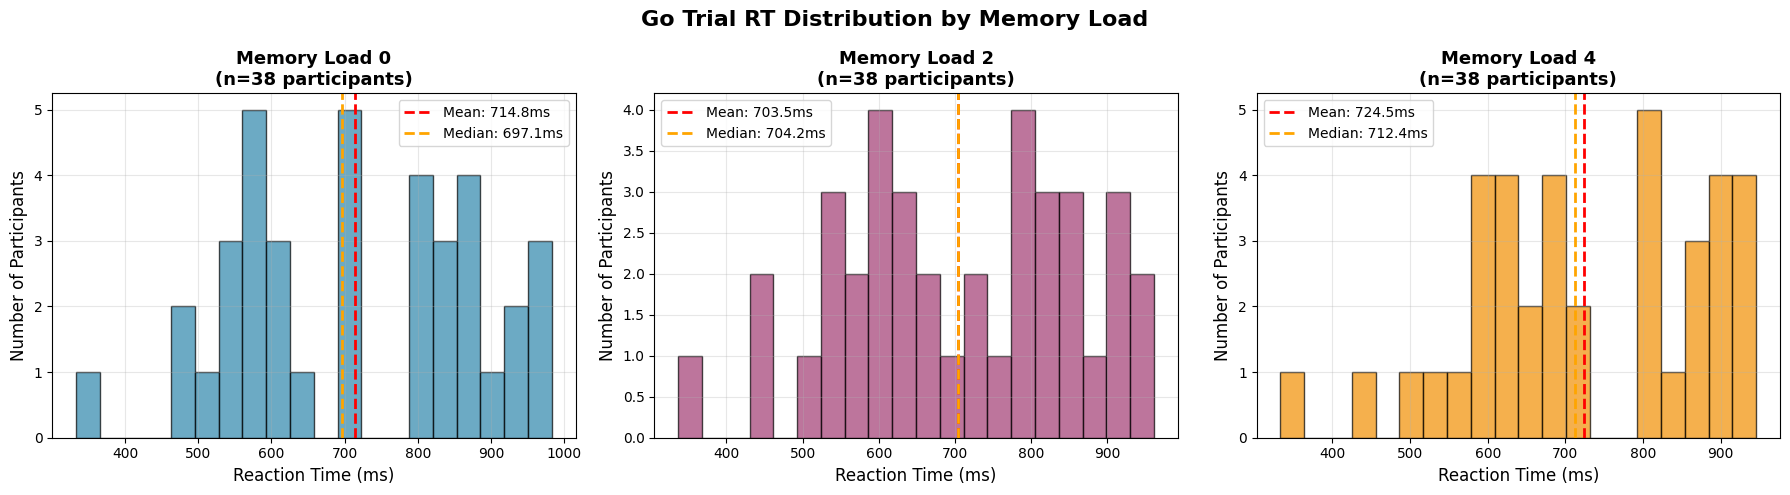


=== Go RT Summary Statistics ===
Memory Load 0: Mean=714.8ms, SD=166.1ms, Median=697.1ms, Range=[332.9, 983.2]ms
Memory Load 2: Mean=703.5ms, SD=158.7ms, Median=704.2ms, Range=[336.6, 961.3]ms
Memory Load 4: Mean=724.5ms, SD=152.7ms, Median=712.4ms, Range=[333.0, 945.7]ms


In [4]:
# Histogram: Go RT by Memory Load
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Go Trial RT Distribution by Memory Load', fontsize=16, fontweight='bold')

colors = ['#2E86AB', '#A23B72', '#F18F01']  # Blue, Purple, Orange
conditions = [
    ('Memory Load 0', 'dual_task_go_wm2_mean_rt', colors[0]),
    ('Memory Load 2', 'dual_task_go_wm4_mean_rt', colors[1]),
    ('Memory Load 4', 'dual_task_go_wm6_mean_rt', colors[2])
]

for idx, (label, column, color) in enumerate(conditions):
    ax = axes[idx]
    data = metrics_data_wm[column].dropna()
    
    # Create histogram
    ax.hist(data, bins=20, alpha=0.7, color=color, edgecolor='black')
    
    # Add mean and median lines
    mean_val = data.mean()
    median_val = data.median()
    ax.axvline(mean_val, color='red', linestyle='--', linewidth=2, 
               label=f'Mean: {mean_val:.1f}ms')
    ax.axvline(median_val, color='orange', linestyle='--', linewidth=2, 
               label=f'Median: {median_val:.1f}ms')
    
    ax.set_xlabel('Reaction Time (ms)', fontsize=12)
    ax.set_ylabel('Number of Participants', fontsize=12)
    ax.set_title(f'{label}\n(n={len(data)} participants)', fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n=== Go RT Summary Statistics ===")
for label, column, _ in conditions:
    data = metrics_data_wm[column].dropna()
    print(f"{label}: Mean={data.mean():.1f}ms, SD={data.std():.1f}ms, "
          f"Median={data.median():.1f}ms, Range=[{data.min():.1f}, {data.max():.1f}]ms")


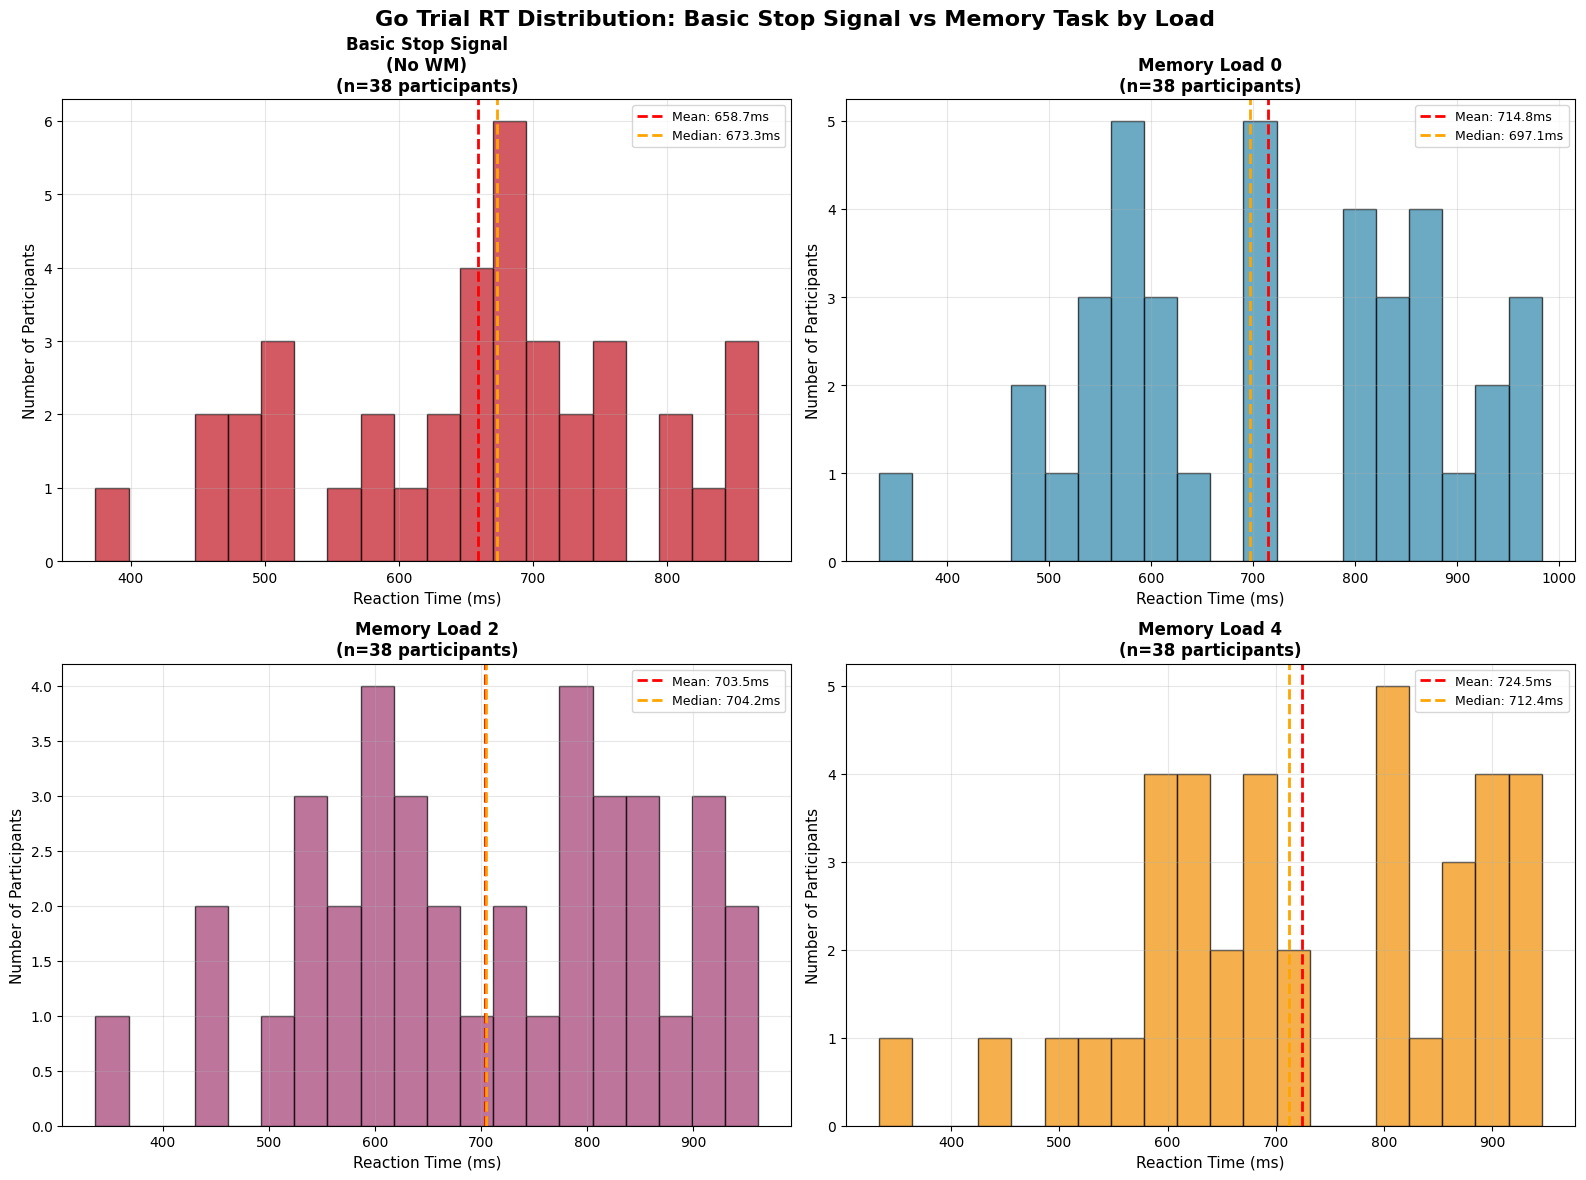


=== Go RT Summary Statistics: Basic Stop Signal vs Memory Task ===
Basic Stop Signal
(No WM): Mean=658.7ms, SD=122.2ms, Median=673.3ms, Range=[373.8, 868.1]ms, n=38
Memory Load 0: Mean=714.8ms, SD=166.1ms, Median=697.1ms, Range=[332.9, 983.2]ms, n=38
Memory Load 2: Mean=703.5ms, SD=158.7ms, Median=704.2ms, Range=[336.6, 961.3]ms, n=38
Memory Load 4: Mean=724.5ms, SD=152.7ms, Median=712.4ms, Range=[333.0, 945.7]ms, n=38

=== RT Cost of Memory Load ===
Memory Load 0 vs Basic Stop Signal: +56.0ms (8.5% increase)
Memory Load 2 vs Basic Stop Signal: +44.8ms (6.8% increase)
Memory Load 4 vs Basic Stop Signal: +65.8ms (10.0% increase)


In [5]:
# Histogram: Compare Basic Stop Signal Go RT with WM Task Go RTs
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Go Trial RT Distribution: Basic Stop Signal vs Memory Task by Load', 
             fontsize=16, fontweight='bold')

colors = ['#C1121F', '#2E86AB', '#A23B72', '#F18F01']  # Red, Blue, Purple, Orange
all_conditions = [
    ('Basic Stop Signal\n(No WM)', 'go_mean_rt', metrics_data_stop, colors[0], axes[0, 0]),
    ('Memory Load 0', 'dual_task_go_wm2_mean_rt', metrics_data_wm, colors[1], axes[0, 1]),
    ('Memory Load 2', 'dual_task_go_wm4_mean_rt', metrics_data_wm, colors[2], axes[1, 0]),
    ('Memory Load 4', 'dual_task_go_wm6_mean_rt', metrics_data_wm, colors[3], axes[1, 1])
]

rt_summary = {}

for label, column, data_source, color, ax in all_conditions:
    data = data_source[column].dropna()
    
    # Create histogram
    ax.hist(data, bins=20, alpha=0.7, color=color, edgecolor='black')
    
    # Add mean and median lines
    mean_val = data.mean()
    median_val = data.median()
    ax.axvline(mean_val, color='red', linestyle='--', linewidth=2, 
               label=f'Mean: {mean_val:.1f}ms')
    ax.axvline(median_val, color='orange', linestyle='--', linewidth=2, 
               label=f'Median: {median_val:.1f}ms')
    
    ax.set_xlabel('Reaction Time (ms)', fontsize=11)
    ax.set_ylabel('Number of Participants', fontsize=11)
    ax.set_title(f'{label}\n(n={len(data)} participants)', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    
    # Store summary stats
    rt_summary[label] = {
        'mean': mean_val,
        'median': median_val,
        'sd': data.std(),
        'min': data.min(),
        'max': data.max(),
        'n': len(data)
    }

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n=== Go RT Summary Statistics: Basic Stop Signal vs Memory Task ===")
for label, stats in rt_summary.items():
    print(f"{label}: Mean={stats['mean']:.1f}ms, SD={stats['sd']:.1f}ms, "
          f"Median={stats['median']:.1f}ms, Range=[{stats['min']:.1f}, {stats['max']:.1f}]ms, n={stats['n']}")

# Calculate RT cost of WM load
print("\n=== RT Cost of Memory Load ===")
baseline_mean = rt_summary['Basic Stop Signal\n(No WM)']['mean']
for load in ['Memory Load 0', 'Memory Load 2', 'Memory Load 4']:
    cost = rt_summary[load]['mean'] - baseline_mean
    print(f"{load} vs Basic Stop Signal: +{cost:.1f}ms ({cost/baseline_mean*100:.1f}% increase)")


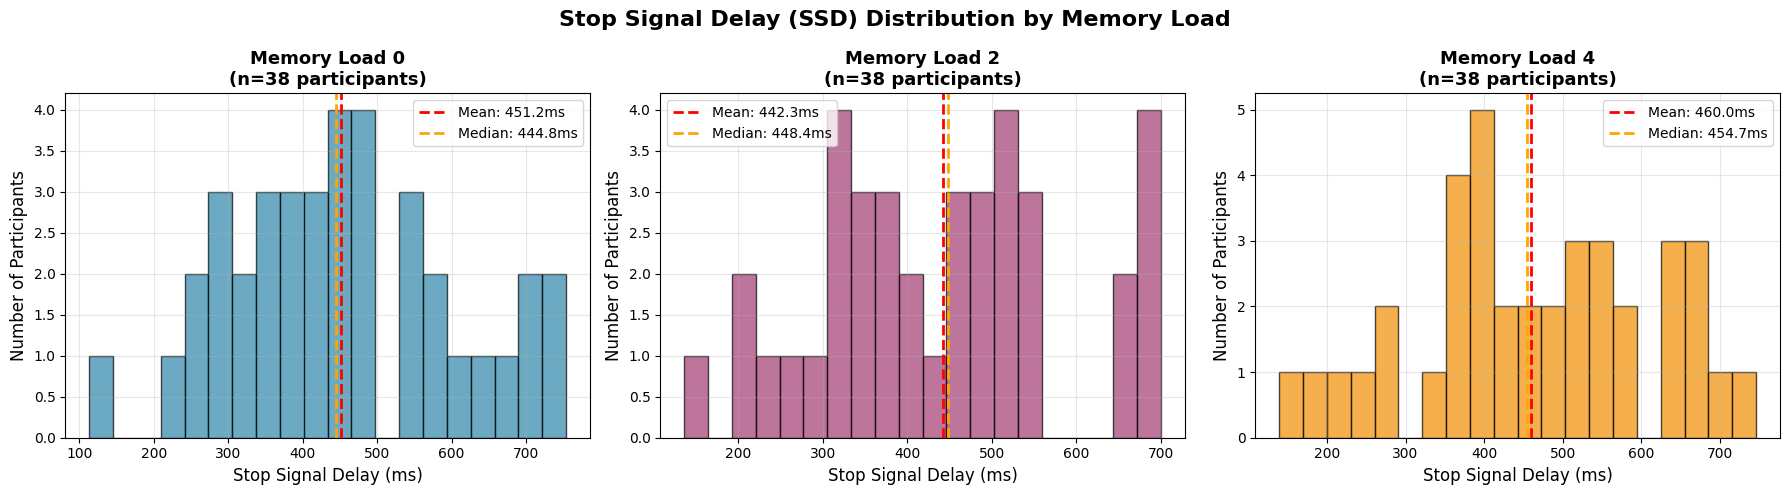


=== SSD Summary Statistics ===
Memory Load 0: Mean=451.2ms, SD=155.4ms, Median=444.8ms, Range=[113.2, 753.8]ms
Memory Load 2: Mean=442.3ms, SD=147.9ms, Median=448.4ms, Range=[135.8, 700.3]ms
Memory Load 4: Mean=460.0ms, SD=152.2ms, Median=454.7ms, Range=[139.2, 745.8]ms


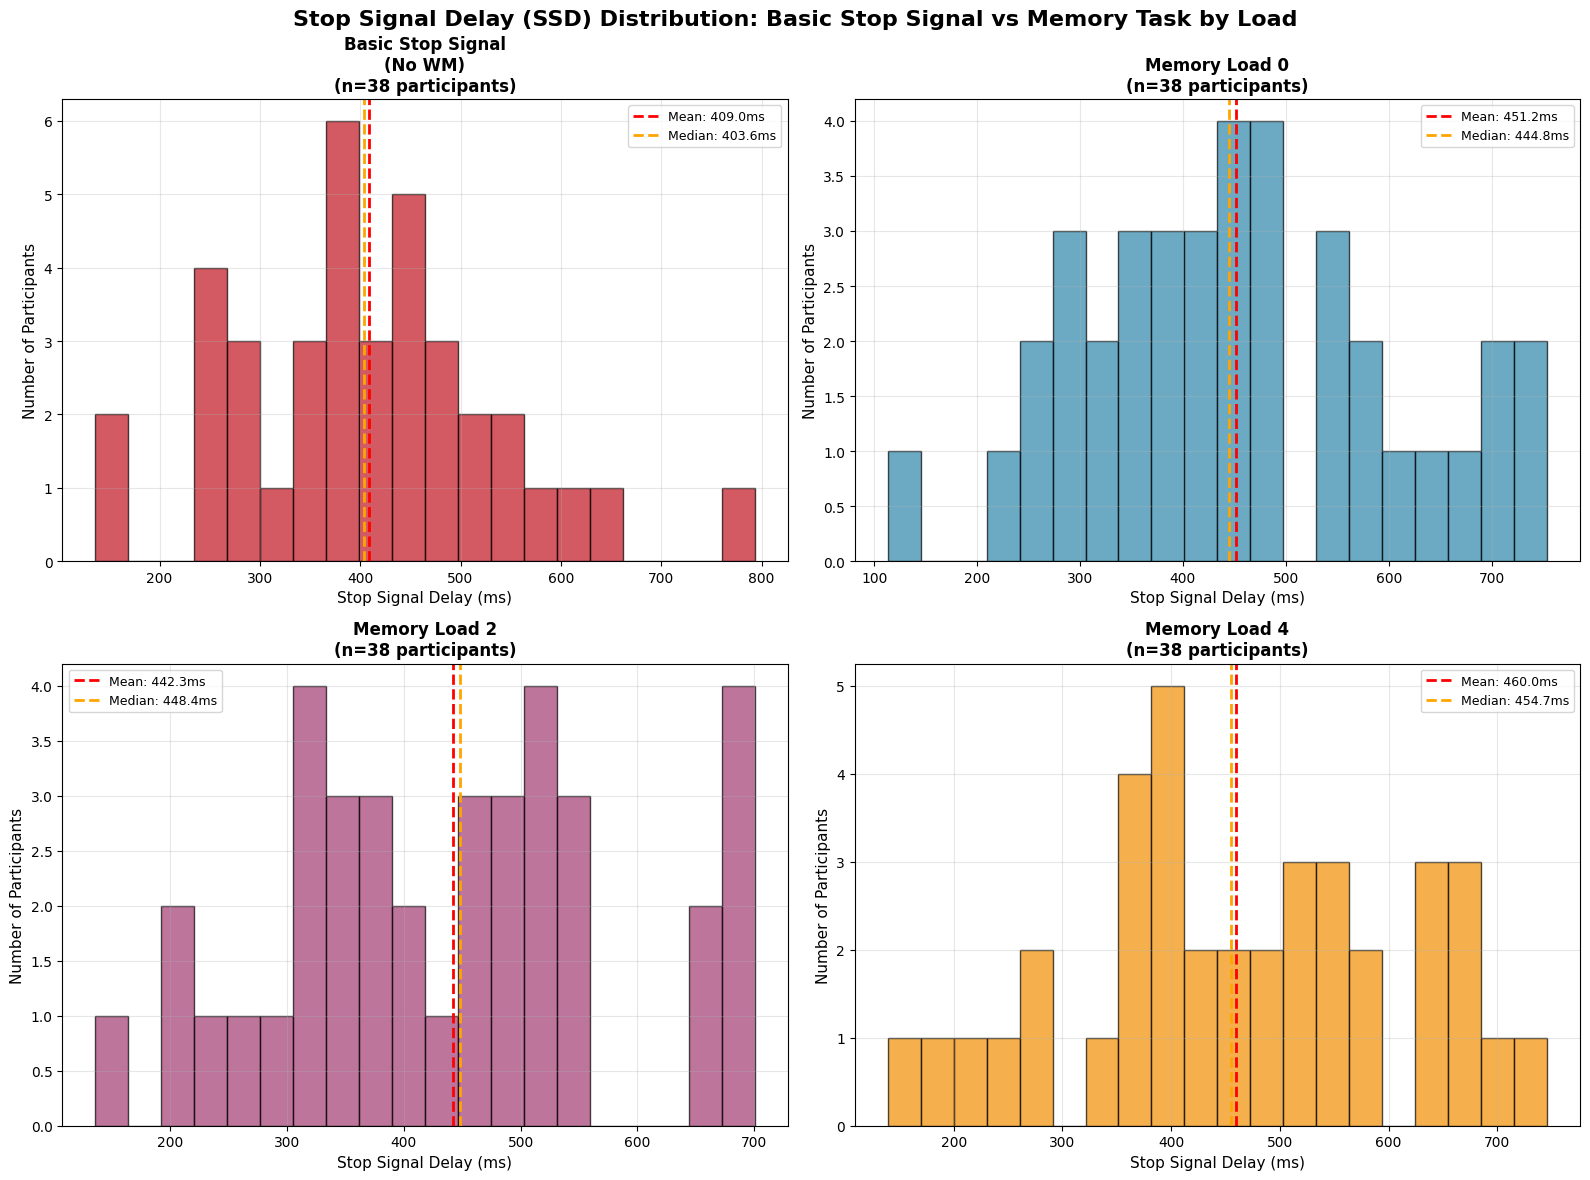


=== SSD Summary Statistics: Basic Stop Signal vs Memory Task ===
Basic Stop Signal
(No WM): Mean=409.0ms, SD=136.2ms, Median=403.6ms, Range=[135.8, 793.1]ms, n=38
Memory Load 0: Mean=451.2ms, SD=155.4ms, Median=444.8ms, Range=[113.2, 753.8]ms, n=38
Memory Load 2: Mean=442.3ms, SD=147.9ms, Median=448.4ms, Range=[135.8, 700.3]ms, n=38
Memory Load 4: Mean=460.0ms, SD=152.2ms, Median=454.7ms, Range=[139.2, 745.8]ms, n=38

=== SSD Difference from Basic Stop Signal ===
Memory Load 0 vs Basic Stop Signal: +42.2ms (+10.3% change)
Memory Load 2 vs Basic Stop Signal: +33.4ms (+8.2% change)
Memory Load 4 vs Basic Stop Signal: +51.0ms (+12.5% change)


In [6]:
# Histogram: SSD (Stop Signal Delay) by Memory Load
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Stop Signal Delay (SSD) Distribution by Memory Load', fontsize=16, fontweight='bold')

colors = ['#2E86AB', '#A23B72', '#F18F01']  # Blue, Purple, Orange
conditions = [
    ('Memory Load 0', 'mean_SSD_wm2', colors[0]),
    ('Memory Load 2', 'mean_SSD_wm4', colors[1]),
    ('Memory Load 4', 'mean_SSD_wm6', colors[2])
]

for idx, (label, column, color) in enumerate(conditions):
    ax = axes[idx]
    data = metrics_data_wm[column].dropna()
    
    # Create histogram
    ax.hist(data, bins=20, alpha=0.7, color=color, edgecolor='black')
    
    # Add mean and median lines
    mean_val = data.mean()
    median_val = data.median()
    ax.axvline(mean_val, color='red', linestyle='--', linewidth=2, 
               label=f'Mean: {mean_val:.1f}ms')
    ax.axvline(median_val, color='orange', linestyle='--', linewidth=2, 
               label=f'Median: {median_val:.1f}ms')
    
    ax.set_xlabel('Stop Signal Delay (ms)', fontsize=12)
    ax.set_ylabel('Number of Participants', fontsize=12)
    ax.set_title(f'{label}\n(n={len(data)} participants)', fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n=== SSD Summary Statistics ===")
for label, column, _ in conditions:
    data = metrics_data_wm[column].dropna()
    print(f"{label}: Mean={data.mean():.1f}ms, SD={data.std():.1f}ms, "
          f"Median={data.median():.1f}ms, Range=[{data.min():.1f}, {data.max():.1f}]ms")

# Histogram: Compare Basic Stop Signal SSD with WM Task SSD by Load
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Stop Signal Delay (SSD) Distribution: Basic Stop Signal vs Memory Task by Load', 
             fontsize=16, fontweight='bold')

colors = ['#C1121F', '#2E86AB', '#A23B72', '#F18F01']  # Red, Blue, Purple, Orange
all_conditions = [
    ('Basic Stop Signal\n(No WM)', 'mean_SSD', metrics_data_stop, colors[0], axes[0, 0]),
    ('Memory Load 0', 'mean_SSD_wm2', metrics_data_wm, colors[1], axes[0, 1]),
    ('Memory Load 2', 'mean_SSD_wm4', metrics_data_wm, colors[2], axes[1, 0]),
    ('Memory Load 4', 'mean_SSD_wm6', metrics_data_wm, colors[3], axes[1, 1])
]

ssd_summary = {}

for label, column, data_source, color, ax in all_conditions:
    data = data_source[column].dropna()
    
    # Create histogram
    ax.hist(data, bins=20, alpha=0.7, color=color, edgecolor='black')
    
    # Add mean and median lines
    mean_val = data.mean()
    median_val = data.median()
    ax.axvline(mean_val, color='red', linestyle='--', linewidth=2, 
               label=f'Mean: {mean_val:.1f}ms')
    ax.axvline(median_val, color='orange', linestyle='--', linewidth=2, 
               label=f'Median: {median_val:.1f}ms')
    
    ax.set_xlabel('Stop Signal Delay (ms)', fontsize=11)
    ax.set_ylabel('Number of Participants', fontsize=11)
    ax.set_title(f'{label}\n(n={len(data)} participants)', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    
    # Store summary stats
    ssd_summary[label] = {
        'mean': mean_val,
        'median': median_val,
        'sd': data.std(),
        'min': data.min(),
        'max': data.max(),
        'n': len(data)
    }

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n=== SSD Summary Statistics: Basic Stop Signal vs Memory Task ===")
for label, stats in ssd_summary.items():
    print(f"{label}: Mean={stats['mean']:.1f}ms, SD={stats['sd']:.1f}ms, "
          f"Median={stats['median']:.1f}ms, Range=[{stats['min']:.1f}, {stats['max']:.1f}]ms, n={stats['n']}")

# Calculate SSD difference from baseline
print("\n=== SSD Difference from Basic Stop Signal ===")
baseline_mean = ssd_summary['Basic Stop Signal\n(No WM)']['mean']
for load in ['Memory Load 0', 'Memory Load 2', 'Memory Load 4']:
    diff = ssd_summary[load]['mean'] - baseline_mean
    print(f"{load} vs Basic Stop Signal: {diff:+.1f}ms ({diff/baseline_mean*100:+.1f}% change)")


## 5. Simple Stop Signal vs Memory Task Go Accuracy by Load

Compare GO trial accuracy between the simple stop signal task (baseline) and the WM task across different load levels, with a horizontal line indicating the simple stop signal baseline mean.

Participants with complete data for both tasks: 38



/var/folders/4n/6xdj3h3x4v94vpyhm5330k280000gn/T/ipykernel_63237/576022261.py:73: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=11, loc='lower left')


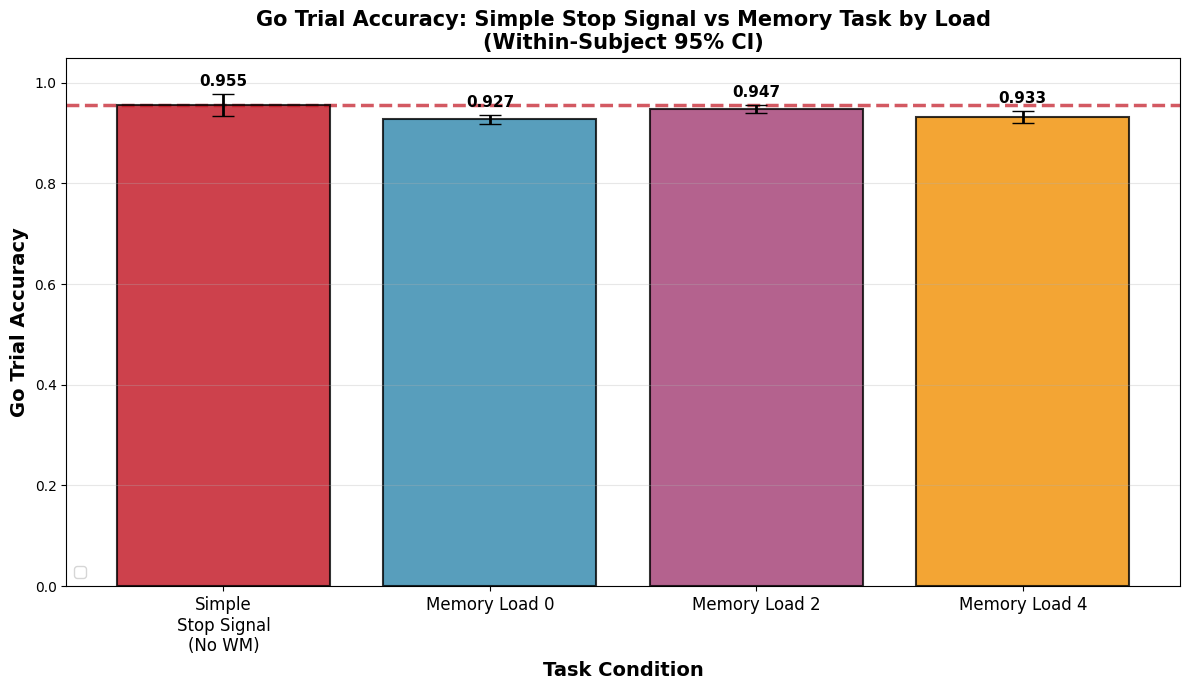


=== Go Trial Accuracy Summary (n=38 participants) ===

Descriptive Statistics:
  Simple Stop Signal (No WM): M=0.955 ± 0.022 (within-subject CI), SD=0.062
  Memory Load 0: M=0.927 ± 0.010 (within-subject CI), SD=0.069
  Memory Load 2: M=0.947 ± 0.008 (within-subject CI), SD=0.061
  Memory Load 4: M=0.933 ± 0.012 (within-subject CI), SD=0.072


/var/folders/4n/6xdj3h3x4v94vpyhm5330k280000gn/T/ipykernel_63237/576022261.py:88: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"  {condition.replace(chr(10), ' ')}: M={all_means[i]:.3f} ± {all_cis[i]:.3f} (within-subject CI), SD={accuracy_matrix[condition_key].std():.3f}")


In [7]:
# Bar plot comparing Simple Stop Signal GO Accuracy with WM Task GO Accuracy by Load
fig, ax = plt.subplots(1, 1, figsize=(12, 7))

# Find participants with data for both tasks
participants_both = list(set(metrics_data_stop['prolific_id']) & set(metrics_data_wm['prolific_id']))

# Filter for participants with complete data
stop_data = metrics_data_stop[metrics_data_stop['prolific_id'].isin(participants_both)]
stop_data = stop_data.dropna(subset=['go_choice_accuracy'])

wm_data = metrics_data_wm[metrics_data_wm['prolific_id'].isin(participants_both)]
wm_data = wm_data.dropna(subset=[
    'dual_task_go_wm2_choice_accuracy', 'dual_task_go_wm4_choice_accuracy', 'dual_task_go_wm6_choice_accuracy'
])

# Get overlapping participants
common_participants = list(set(stop_data['prolific_id']) & set(wm_data['prolific_id']))
stop_data_filtered = stop_data[stop_data['prolific_id'].isin(common_participants)]
wm_data_filtered = wm_data[wm_data['prolific_id'].isin(common_participants)]

print(f"Participants with complete data for both tasks: {len(common_participants)}\n")

# Prepare data for within-subject CI calculation
# Need to align participants and create a matrix with all conditions
stop_data_filtered = stop_data_filtered.set_index('prolific_id')
wm_data_filtered = wm_data_filtered.set_index('prolific_id')

# Create data matrix for within-subject CIs (participants x conditions)
accuracy_matrix = pd.DataFrame({
    'Simple_Stop': stop_data_filtered['go_choice_accuracy'],
    'WM_Load_0': wm_data_filtered['dual_task_go_wm2_choice_accuracy'],
    'WM_Load_2': wm_data_filtered['dual_task_go_wm4_choice_accuracy'],
    'WM_Load_4': wm_data_filtered['dual_task_go_wm6_choice_accuracy']
})

# Calculate within-subject CIs
all_cis = calculate_within_subject_ci(accuracy_matrix)

# Calculate means for each condition
all_means = np.array([
    accuracy_matrix['Simple_Stop'].mean(),
    accuracy_matrix['WM_Load_0'].mean(),
    accuracy_matrix['WM_Load_2'].mean(),
    accuracy_matrix['WM_Load_4'].mean()
])

# Store simple stop mean for reference line
simple_stop_mean = all_means[0]

# Set up bar positions and colors
conditions = ['Simple\nStop Signal\n(No WM)', 'Memory Load 0', 'Memory Load 2', 'Memory Load 4']
x_pos = np.arange(len(conditions))
colors = ['#C1121F', '#2E86AB', '#A23B72', '#F18F01']  # Red for baseline, then blue/purple/orange

# Create bar plot
bars = ax.bar(x_pos, all_means, yerr=all_cis, capsize=8,
              alpha=0.8, color=colors, edgecolor='black', linewidth=1.5,
              error_kw={'linewidth': 2, 'ecolor': 'black'})

# Add horizontal line for simple stop signal mean
ax.axhline(y=simple_stop_mean, color='#C1121F', linestyle='--', linewidth=2.5, 
           alpha=0.7, zorder=0)

# Formatting
ax.set_xlabel('Task Condition', fontsize=14, fontweight='bold')
ax.set_ylabel('Go Trial Accuracy', fontsize=14, fontweight='bold')
ax.set_title('Go Trial Accuracy: Simple Stop Signal vs Memory Task by Load\n(Within-Subject 95% CI)', 
             fontsize=15, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(conditions, fontsize=12)
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3, axis='y')
ax.legend(fontsize=11, loc='lower left')

# Add value labels on bars
for i, (bar, mean, ci) in enumerate(zip(bars, all_means, all_cis)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2., height + ci + 0.01,
            f'{mean:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n=== Go Trial Accuracy Summary (n={len(common_participants)} participants) ===")
print("\nDescriptive Statistics:")
for i, condition in enumerate(conditions):
    condition_key = ['Simple_Stop', 'WM_Load_0', 'WM_Load_2', 'WM_Load_4'][i]
    print(f"  {condition.replace(chr(10), ' ')}: M={all_means[i]:.3f} ± {all_cis[i]:.3f} (within-subject CI), SD={accuracy_matrix[condition_key].std():.3f}")


## 6. Simple Stop Signal vs Memory Task GO RT by Load

Compare GO trial reaction times between the simple stop signal task (baseline) and the WM task across different load levels, with a horizontal line indicating the simple stop signal baseline mean.

Participants with complete data for both tasks: 38



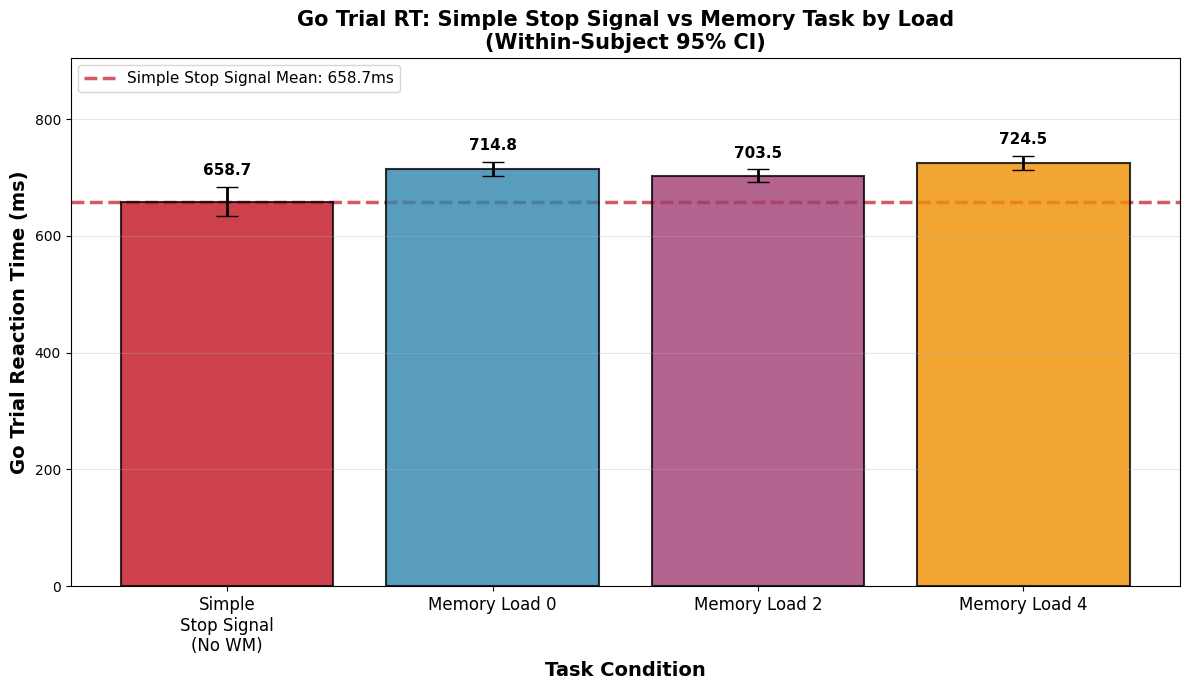


=== GO RT Comparison Summary (n=38 participants) ===

Simple Stop Signal (No WM): 658.7ms ± 25.0ms (within-subject 95% CI)
WM Load 0: 714.8ms ± 12.6ms (within-subject 95% CI)
WM Load 2: 703.5ms ± 10.7ms (within-subject 95% CI)
WM Load 4: 724.5ms ± 12.1ms (within-subject 95% CI)

=== RT Cost relative to Simple Stop Signal ===
WM Load 0: +56.0ms (8.5%)
WM Load 2: +44.8ms (6.8%)
WM Load 4: +65.8ms (10.0%)


/var/folders/4n/6xdj3h3x4v94vpyhm5330k280000gn/T/ipykernel_63237/11415595.py:88: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"Simple Stop Signal (No WM): {all_means[0]:.1f}ms ± {all_cis[0]:.1f}ms (within-subject 95% CI)")
/var/folders/4n/6xdj3h3x4v94vpyhm5330k280000gn/T/ipykernel_63237/11415595.py:89: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"WM Load 0: {all_means[1]:.1f}ms ± {all_cis[1]:.1f}ms (within-subject 95% CI)")
/var/folders/4n/6xdj3h3x4v94vpyhm5330k280000gn/T/ipykernel_63237/11415595.py:90: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, i

In [8]:
# Bar plot comparing Simple Stop Signal GO RT with WM Task GO RT by Load
fig, ax = plt.subplots(1, 1, figsize=(12, 7))

# Find participants with data for both tasks
participants_both = list(set(metrics_data_stop['prolific_id']) & set(metrics_data_wm['prolific_id']))

# Filter for participants with complete data
stop_data = metrics_data_stop[metrics_data_stop['prolific_id'].isin(participants_both)]
stop_data = stop_data.dropna(subset=['go_mean_rt'])

wm_data = metrics_data_wm[metrics_data_wm['prolific_id'].isin(participants_both)]
wm_data = wm_data.dropna(subset=[
    'dual_task_go_wm2_mean_rt', 'dual_task_go_wm4_mean_rt', 'dual_task_go_wm6_mean_rt'
])

# Get overlapping participants
common_participants = list(set(stop_data['prolific_id']) & set(wm_data['prolific_id']))
stop_data_filtered = stop_data[stop_data['prolific_id'].isin(common_participants)]
wm_data_filtered = wm_data[wm_data['prolific_id'].isin(common_participants)]

print(f"Participants with complete data for both tasks: {len(common_participants)}\n")

# Prepare data for within-subject CI calculation
# Need to align participants and create a matrix with all conditions
stop_data_filtered = stop_data_filtered.set_index('prolific_id')
wm_data_filtered = wm_data_filtered.set_index('prolific_id')

# Create data matrix for within-subject CIs (participants x conditions)
rt_matrix = pd.DataFrame({
    'Simple_Stop': stop_data_filtered['go_mean_rt'],
    'WM_Load_0': wm_data_filtered['dual_task_go_wm2_mean_rt'],
    'WM_Load_2': wm_data_filtered['dual_task_go_wm4_mean_rt'],
    'WM_Load_4': wm_data_filtered['dual_task_go_wm6_mean_rt']
})

# Calculate within-subject CIs
all_cis = calculate_within_subject_ci(rt_matrix)

# Calculate means for each condition
all_means = np.array([
    rt_matrix['Simple_Stop'].mean(),
    rt_matrix['WM_Load_0'].mean(),
    rt_matrix['WM_Load_2'].mean(),
    rt_matrix['WM_Load_4'].mean()
])

# Store simple stop mean for reference line
simple_stop_mean = all_means[0]

# Set up bar positions and colors
conditions = ['Simple\nStop Signal\n(No WM)', 'Memory Load 0', 'Memory Load 2', 'Memory Load 4']
x_pos = np.arange(len(conditions))
colors = ['#C1121F', '#2E86AB', '#A23B72', '#F18F01']  # Red for baseline, then blue/purple/orange

# all_means and all_cis are already calculated above with within-subject CIs

# Create bar plot
bars = ax.bar(x_pos, all_means, yerr=all_cis, capsize=8,
              alpha=0.8, color=colors, edgecolor='black', linewidth=1.5,
              error_kw={'linewidth': 2, 'ecolor': 'black'})

# Add horizontal line for simple stop signal mean
ax.axhline(y=simple_stop_mean, color='#C1121F', linestyle='--', linewidth=2.5, 
           alpha=0.7, label=f'Simple Stop Signal Mean: {simple_stop_mean:.1f}ms', zorder=0)

# Formatting
ax.set_xlabel('Task Condition', fontsize=14, fontweight='bold')
ax.set_ylabel('Go Trial Reaction Time (ms)', fontsize=14, fontweight='bold')
ax.set_title('Go Trial RT: Simple Stop Signal vs Memory Task by Load\n(Within-Subject 95% CI)', 
             fontsize=15, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(conditions, fontsize=12)
ax.set_ylim(0, max(all_means) * 1.25)
ax.grid(True, alpha=0.3, axis='y')
ax.legend(fontsize=11, loc='upper left')

# Add value labels on bars
for i, (bar, mean, ci) in enumerate(zip(bars, all_means, all_cis)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2., height + ci + 15,
            f'{mean:.1f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# Print summary statistics
print(f"\n=== GO RT Comparison Summary (n={len(common_participants)} participants) ===\n")
print(f"Simple Stop Signal (No WM): {all_means[0]:.1f}ms ± {all_cis[0]:.1f}ms (within-subject 95% CI)")
print(f"WM Load 0: {all_means[1]:.1f}ms ± {all_cis[1]:.1f}ms (within-subject 95% CI)")
print(f"WM Load 2: {all_means[2]:.1f}ms ± {all_cis[2]:.1f}ms (within-subject 95% CI)")
print(f"WM Load 4: {all_means[3]:.1f}ms ± {all_cis[3]:.1f}ms (within-subject 95% CI)")

print(f"\n=== RT Cost relative to Simple Stop Signal ===")
print(f"WM Load 0: +{all_means[1] - simple_stop_mean:.1f}ms ({(all_means[1] - simple_stop_mean)/simple_stop_mean*100:.1f}%)")
print(f"WM Load 2: +{all_means[2] - simple_stop_mean:.1f}ms ({(all_means[2] - simple_stop_mean)/simple_stop_mean*100:.1f}%)")
print(f"WM Load 4: +{all_means[3] - simple_stop_mean:.1f}ms ({(all_means[3] - simple_stop_mean)/simple_stop_mean*100:.1f}%)")


## 7. Probe Response RT by Memory Load

Analyze probe (memory recognition) response times across different WM load levels.

Participants with complete probe RT data: 38



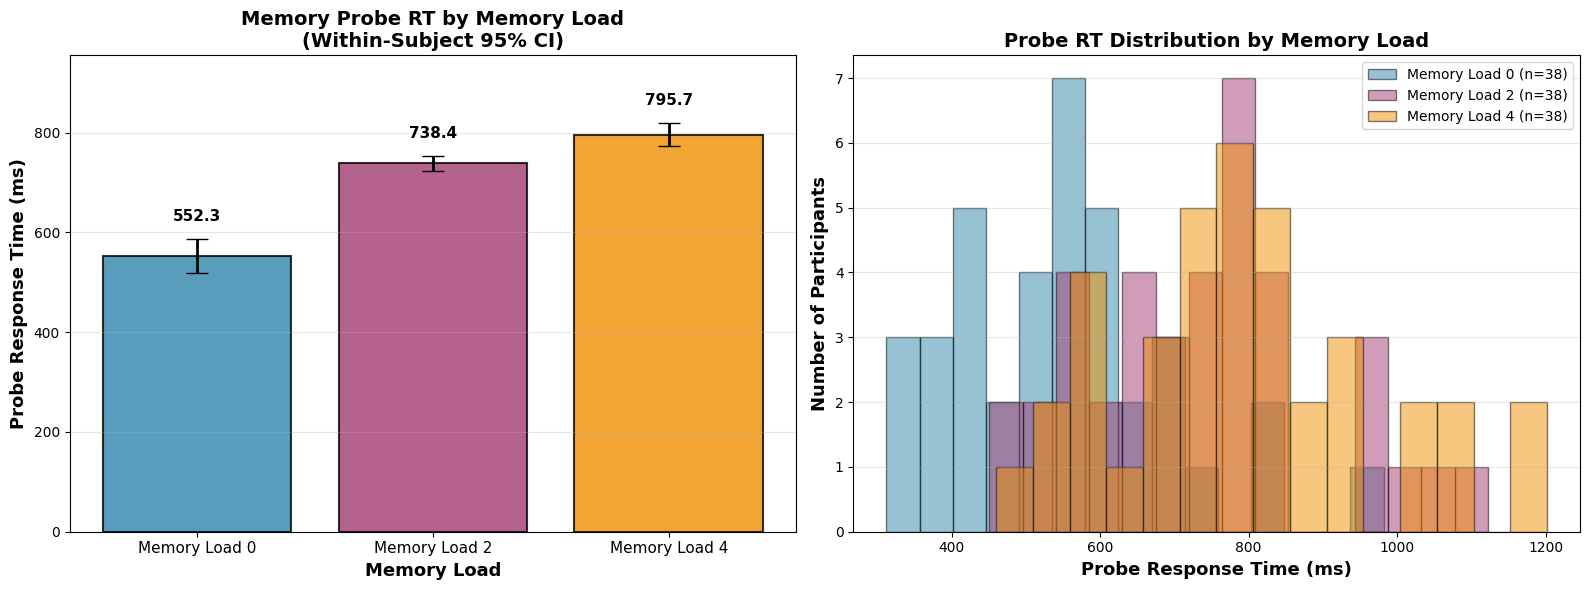

=== Probe RT Summary Statistics ===
Memory Load 0: 552.3ms ± 34.3ms (within-subject CI)
  SD=149.1ms, Range=[311.9, 981.9]ms, n=38
Memory Load 2: 738.4ms ± 15.6ms (within-subject CI)
  SD=159.1ms, Range=[450.7, 1122.3]ms, n=38
Memory Load 4: 795.7ms ± 23.1ms (within-subject CI)
  SD=176.3ms, Range=[459.6, 1202.0]ms, n=38

=== Probe RT Increase by Memory Load ===
Memory Load 2 vs Memory Load 0: +186.0ms (33.7% increase)
Memory Load 4 vs Memory Load 0: +243.4ms (44.1% increase)


/var/folders/4n/6xdj3h3x4v94vpyhm5330k280000gn/T/ipykernel_63237/1703157281.py:82: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ci = probe_rt_cis[i]


In [9]:
# Probe RT Analysis by Memory Load
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Get participants with complete probe data
complete_probe_data = metrics_data_wm.dropna(subset=[
    'probe_wm2_mean_rt',
    'probe_wm4_mean_rt',
    'probe_wm6_mean_rt'
])

print(f"Participants with complete probe RT data: {len(complete_probe_data)}\n")

# Prepare data matrix for within-subject CI calculation
probe_rt_matrix = complete_probe_data[[
    'probe_wm2_mean_rt',
    'probe_wm4_mean_rt',
    'probe_wm6_mean_rt'
]]

# Calculate within-subject CIs
probe_rt_cis = calculate_within_subject_ci(probe_rt_matrix)

# Calculate means
probe_rt_means = np.array([
    probe_rt_matrix.iloc[:, 0].mean(),
    probe_rt_matrix.iloc[:, 1].mean(),
    probe_rt_matrix.iloc[:, 2].mean()
])

conditions = ['Memory Load 0', 'Memory Load 2', 'Memory Load 4']
x_pos = np.arange(len(conditions))
colors = ['#2E86AB', '#A23B72', '#F18F01']

# === BAR PLOT WITH WITHIN-SUBJECT CIs ===
ax1 = axes[0]
bars = ax1.bar(x_pos, probe_rt_means, yerr=probe_rt_cis, capsize=8,
               alpha=0.8, color=colors, edgecolor='black', linewidth=1.5,
               error_kw={'linewidth': 2, 'ecolor': 'black'})

ax1.set_xlabel('Memory Load', fontsize=13, fontweight='bold')
ax1.set_ylabel('Probe Response Time (ms)', fontsize=13, fontweight='bold')
ax1.set_title('Memory Probe RT by Memory Load\n(Within-Subject 95% CI)', 
              fontsize=14, fontweight='bold')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(conditions, fontsize=11)
ax1.set_ylim(0, max(probe_rt_means) * 1.2)
ax1.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for i, (bar, mean, ci) in enumerate(zip(bars, probe_rt_means, probe_rt_cis)):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width() / 2., height + ci + 30,
             f'{mean:.1f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# === HISTOGRAM OF PROBE RTs BY LOAD ===
ax2 = axes[1]

probe_data = [
    metrics_data_wm['probe_wm2_mean_rt'].dropna(),
    metrics_data_wm['probe_wm4_mean_rt'].dropna(),
    metrics_data_wm['probe_wm6_mean_rt'].dropna()
]

# Create overlapping histograms
for i, (data, color, label) in enumerate(zip(probe_data, colors, conditions)):
    ax2.hist(data, bins=15, alpha=0.5, color=color, edgecolor='black', 
             label=f'{label} (n={len(data)})', density=False)

ax2.set_xlabel('Probe Response Time (ms)', fontsize=13, fontweight='bold')
ax2.set_ylabel('Number of Participants', fontsize=13, fontweight='bold')
ax2.set_title('Probe RT Distribution by Memory Load', fontsize=14, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Print summary statistics
print("=== Probe RT Summary Statistics ===")
for i, condition in enumerate(conditions):
    mean = probe_rt_means[i]
    ci = probe_rt_cis[i]
    data = probe_data[i]
    print(f"{condition}: {mean:.1f}ms ± {ci:.1f}ms (within-subject CI)")
    print(f"  SD={data.std():.1f}ms, Range=[{data.min():.1f}, {data.max():.1f}]ms, n={len(data)}")

# Calculate probe RT increase from load
print("\n=== Probe RT Increase by Memory Load ===")
baseline_probe = probe_rt_means[0]
for i in range(1, len(conditions)):
    increase = probe_rt_means[i] - baseline_probe
    percent = (increase / baseline_probe) * 100
    print(f"{conditions[i]} vs {conditions[0]}: +{increase:.1f}ms ({percent:.1f}% increase)")


## 8. Probe Response Accuracy by Memory Load

Analyze probe (memory recognition) accuracy across different WM load levels.

Participants with complete probe accuracy data: 38



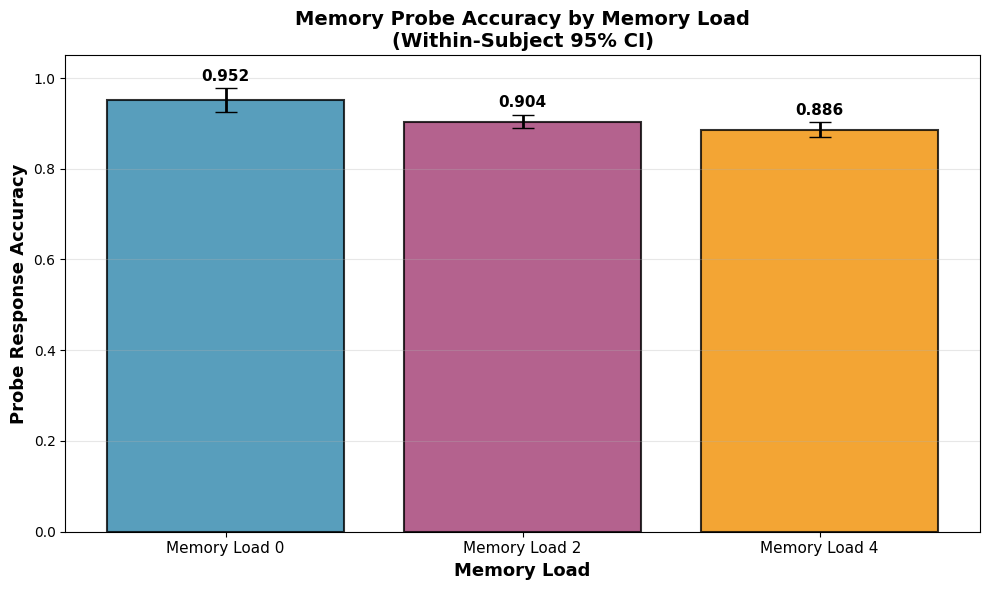

=== Probe Accuracy Summary Statistics ===
Memory Load 0: 0.952 ± 0.026 (within-subject CI)
  SD=0.079, Range=[0.694, 1.000], n=38
Memory Load 2: 0.904 ± 0.015 (within-subject CI)
  SD=0.090, Range=[0.674, 0.979], n=38
Memory Load 4: 0.886 ± 0.016 (within-subject CI)
  SD=0.100, Range=[0.646, 0.986], n=38

=== Probe Accuracy Decline by Memory Load ===
Memory Load 2 vs Memory Load 0: -0.048 (-5.0%)
Memory Load 4 vs Memory Load 0: -0.066 (-6.9%)


/var/folders/4n/6xdj3h3x4v94vpyhm5330k280000gn/T/ipykernel_63237/1879951505.py:61: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ci = probe_acc_cis[i]


In [10]:
# Probe Accuracy Analysis by Memory Load
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

# Get participants with complete probe accuracy data
complete_probe_acc_data = metrics_data_wm.dropna(subset=[
    'probe_wm2_response_accuracy',
    'probe_wm4_response_accuracy',
    'probe_wm6_response_accuracy'
])

print(f"Participants with complete probe accuracy data: {len(complete_probe_acc_data)}\n")

# Prepare data matrix for within-subject CI calculation
probe_acc_matrix = complete_probe_acc_data[[
    'probe_wm2_response_accuracy',
    'probe_wm4_response_accuracy',
    'probe_wm6_response_accuracy'
]]

# Calculate within-subject CIs
probe_acc_cis = calculate_within_subject_ci(probe_acc_matrix)

# Calculate means
probe_acc_means = np.array([
    probe_acc_matrix.iloc[:, 0].mean(),
    probe_acc_matrix.iloc[:, 1].mean(),
    probe_acc_matrix.iloc[:, 2].mean()
])

conditions = ['Memory Load 0', 'Memory Load 2', 'Memory Load 4']
x_pos = np.arange(len(conditions))
colors = ['#2E86AB', '#A23B72', '#F18F01']

# === BAR PLOT WITH WITHIN-SUBJECT CIs ===
bars = ax.bar(x_pos, probe_acc_means, yerr=probe_acc_cis, capsize=8,
              alpha=0.8, color=colors, edgecolor='black', linewidth=1.5,
              error_kw={'linewidth': 2, 'ecolor': 'black'})

ax.set_xlabel('Memory Load', fontsize=13, fontweight='bold')
ax.set_ylabel('Probe Response Accuracy', fontsize=13, fontweight='bold')
ax.set_title('Memory Probe Accuracy by Memory Load\n(Within-Subject 95% CI)', 
             fontsize=14, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(conditions, fontsize=11)
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for i, (bar, mean, ci) in enumerate(zip(bars, probe_acc_means, probe_acc_cis)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2., height + ci + 0.01,
            f'{mean:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# Print summary statistics
print("=== Probe Accuracy Summary Statistics ===")
for i, condition in enumerate(conditions):
    mean = probe_acc_means[i]
    ci = probe_acc_cis[i]
    data = metrics_data_wm[f'probe_wm{[2,4,6][i]}_response_accuracy'].dropna()
    print(f"{condition}: {mean:.3f} ± {ci:.3f} (within-subject CI)")
    print(f"  SD={data.std():.3f}, Range=[{data.min():.3f}, {data.max():.3f}], n={len(data)}")

# Calculate accuracy decline from load
print("\n=== Probe Accuracy Decline by Memory Load ===")
baseline_acc = probe_acc_means[0]
for i in range(1, len(conditions)):
    decline = probe_acc_means[i] - baseline_acc
    percent = (decline / baseline_acc) * 100
    print(f"{conditions[i]} vs {conditions[0]}: {decline:+.3f} ({percent:+.1f}%)")


## 9. SSRT (Stop Signal Reaction Time) by Memory Load

Analyze SSRT across simple stop signal task and WM task by load level. SSRT = Mean Go RT - Mean SSD, representing the time required to inhibit a response.

Participants with complete SSRT data for both tasks: 38



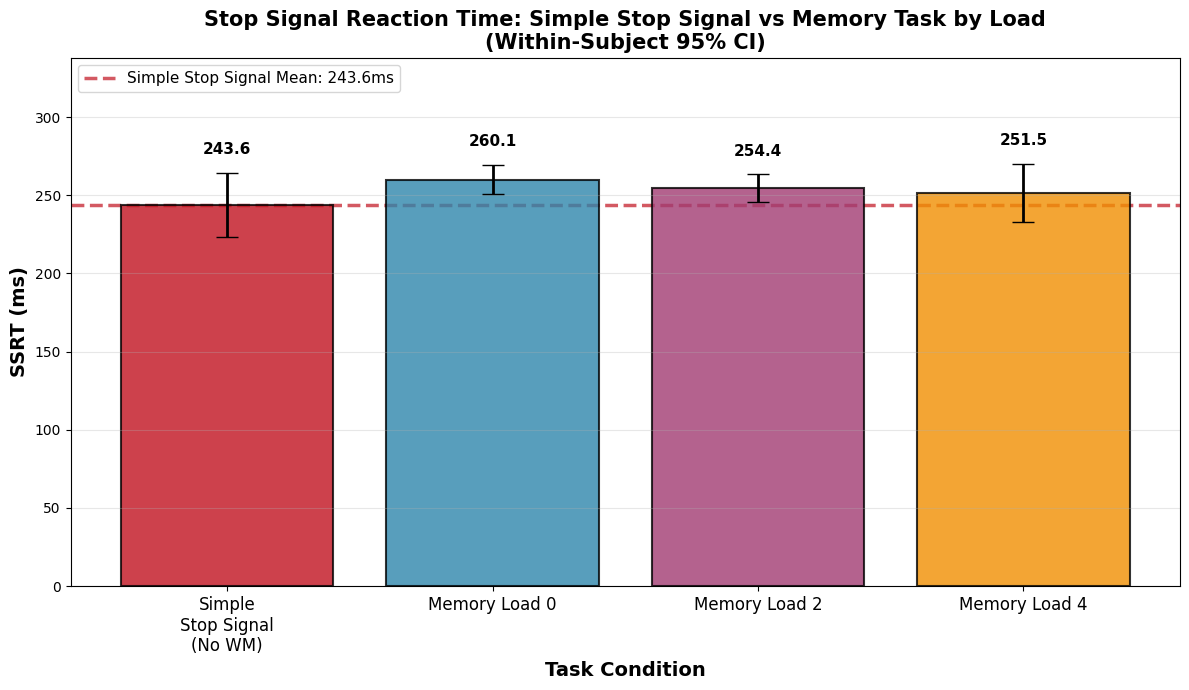


=== SSRT Comparison Summary (n=38 participants) ===

Simple Stop Signal (No WM): 243.6ms ± 20.6ms (within-subject 95% CI)
WM Load 0: 260.1ms ± 9.4ms (within-subject 95% CI)
WM Load 2: 254.4ms ± 9.0ms (within-subject 95% CI)
WM Load 4: 251.5ms ± 18.5ms (within-subject 95% CI)

=== SSRT Change relative to Simple Stop Signal ===
WM Load 0: +16.4ms (+6.7%)
WM Load 2: +10.8ms (+4.4%)
WM Load 4: +7.8ms (+3.2%)

=== SSRT Change across WM Loads ===
WM Load 2 vs WM Load 0: -5.6ms (-2.2%)
WM Load 4 vs WM Load 0: -8.6ms (-3.3%)
WM Load 4 vs WM Load 2: -3.0ms (-1.2%)


/var/folders/4n/6xdj3h3x4v94vpyhm5330k280000gn/T/ipykernel_63237/277524844.py:86: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"Simple Stop Signal (No WM): {all_means[0]:.1f}ms ± {all_cis[0]:.1f}ms (within-subject 95% CI)")
/var/folders/4n/6xdj3h3x4v94vpyhm5330k280000gn/T/ipykernel_63237/277524844.py:87: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"WM Load 0: {all_means[1]:.1f}ms ± {all_cis[1]:.1f}ms (within-subject 95% CI)")
/var/folders/4n/6xdj3h3x4v94vpyhm5330k280000gn/T/ipykernel_63237/277524844.py:88: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version

In [11]:
# SSRT Comparison: Simple Stop Signal vs Memory Task by Load
fig, ax = plt.subplots(1, 1, figsize=(12, 7))

# Find participants with data for both tasks
participants_both = list(set(metrics_data_stop['prolific_id']) & set(metrics_data_wm['prolific_id']))

# Filter for participants with complete SSRT data
stop_data = metrics_data_stop[metrics_data_stop['prolific_id'].isin(participants_both)]
stop_data = stop_data.dropna(subset=['SSRT'])

wm_data = metrics_data_wm[metrics_data_wm['prolific_id'].isin(participants_both)]
wm_data = wm_data.dropna(subset=['SSRT_wm2', 'SSRT_wm4', 'SSRT_wm6'])

# Get overlapping participants
common_participants = list(set(stop_data['prolific_id']) & set(wm_data['prolific_id']))
stop_data_filtered = stop_data[stop_data['prolific_id'].isin(common_participants)]
wm_data_filtered = wm_data[wm_data['prolific_id'].isin(common_participants)]

print(f"Participants with complete SSRT data for both tasks: {len(common_participants)}\n")

# Prepare data for within-subject CI calculation
# Need to align participants and create a matrix with all conditions
stop_data_filtered = stop_data_filtered.set_index('prolific_id')
wm_data_filtered = wm_data_filtered.set_index('prolific_id')

# Create data matrix for within-subject CIs (participants x conditions)
ssrt_matrix = pd.DataFrame({
    'Simple_Stop': stop_data_filtered['SSRT'],
    'WM_Load_0': wm_data_filtered['SSRT_wm2'],
    'WM_Load_2': wm_data_filtered['SSRT_wm4'],
    'WM_Load_4': wm_data_filtered['SSRT_wm6']
})

# Calculate within-subject CIs
all_cis = calculate_within_subject_ci(ssrt_matrix)

# Calculate means for each condition
all_means = np.array([
    ssrt_matrix['Simple_Stop'].mean(),
    ssrt_matrix['WM_Load_0'].mean(),
    ssrt_matrix['WM_Load_2'].mean(),
    ssrt_matrix['WM_Load_4'].mean()
])

# Store simple stop mean for reference line
simple_stop_mean = all_means[0]

# Set up bar positions and colors
conditions = ['Simple\nStop Signal\n(No WM)', 'Memory Load 0', 'Memory Load 2', 'Memory Load 4']
x_pos = np.arange(len(conditions))
colors = ['#C1121F', '#2E86AB', '#A23B72', '#F18F01']  # Red for baseline, then blue/purple/orange

# all_means and all_cis are already calculated above with within-subject CIs

# Create bar plot
bars = ax.bar(x_pos, all_means, yerr=all_cis, capsize=8,
              alpha=0.8, color=colors, edgecolor='black', linewidth=1.5,
              error_kw={'linewidth': 2, 'ecolor': 'black'})

# Add horizontal line for simple stop signal mean
ax.axhline(y=simple_stop_mean, color='#C1121F', linestyle='--', linewidth=2.5, 
           alpha=0.7, label=f'Simple Stop Signal Mean: {simple_stop_mean:.1f}ms', zorder=0)

# Formatting
ax.set_xlabel('Task Condition', fontsize=14, fontweight='bold')
ax.set_ylabel('SSRT (ms)', fontsize=14, fontweight='bold')
ax.set_title('Stop Signal Reaction Time: Simple Stop Signal vs Memory Task by Load\n(Within-Subject 95% CI)', 
             fontsize=15, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(conditions, fontsize=12)
ax.set_ylim(0, max(all_means) * 1.3)
ax.grid(True, alpha=0.3, axis='y')
ax.legend(fontsize=11, loc='upper left')

# Add value labels on bars
for i, (bar, mean, ci) in enumerate(zip(bars, all_means, all_cis)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2., height + ci + 10,
            f'{mean:.1f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# Print summary statistics
print(f"\n=== SSRT Comparison Summary (n={len(common_participants)} participants) ===\n")
print(f"Simple Stop Signal (No WM): {all_means[0]:.1f}ms ± {all_cis[0]:.1f}ms (within-subject 95% CI)")
print(f"WM Load 0: {all_means[1]:.1f}ms ± {all_cis[1]:.1f}ms (within-subject 95% CI)")
print(f"WM Load 2: {all_means[2]:.1f}ms ± {all_cis[2]:.1f}ms (within-subject 95% CI)")
print(f"WM Load 4: {all_means[3]:.1f}ms ± {all_cis[3]:.1f}ms (within-subject 95% CI)")

print(f"\n=== SSRT Change relative to Simple Stop Signal ===")
print(f"WM Load 0: {all_means[1] - simple_stop_mean:+.1f}ms ({(all_means[1] - simple_stop_mean)/simple_stop_mean*100:+.1f}%)")
print(f"WM Load 2: {all_means[2] - simple_stop_mean:+.1f}ms ({(all_means[2] - simple_stop_mean)/simple_stop_mean*100:+.1f}%)")
print(f"WM Load 4: {all_means[3] - simple_stop_mean:+.1f}ms ({(all_means[3] - simple_stop_mean)/simple_stop_mean*100:+.1f}%)")

print(f"\n=== SSRT Change across WM Loads ===")
print(f"WM Load 2 vs WM Load 0: {all_means[2] - all_means[1]:+.1f}ms ({(all_means[2] - all_means[1])/all_means[1]*100:+.1f}%)")
print(f"WM Load 4 vs WM Load 0: {all_means[3] - all_means[1]:+.1f}ms ({(all_means[3] - all_means[1])/all_means[1]*100:+.1f}%)")
print(f"WM Load 4 vs WM Load 2: {all_means[3] - all_means[2]:+.1f}ms ({(all_means[3] - all_means[2])/all_means[2]*100:+.1f}%)")


## 10. Repeated Measures ANOVA: SSRT by Condition

Proper repeated measures ANOVA with:
- Mauchly's test of sphericity
- Greenhouse-Geisser correction (if sphericity violated)
- Post-hoc pairwise comparisons with Bonferroni correction

Run an ANOVA on the SSRT to test for effects of the memory load condition

In [12]:
import pingouin as pg

print("="*70)
print("REPEATED MEASURES ANOVA: SSRT Across All Conditions")
print("="*70)

# Find participants with complete SSRT data for both tasks
participants_both = list(set(metrics_data_stop['prolific_id']) & set(metrics_data_wm['prolific_id']))

# Filter for participants with complete SSRT data
stop_data = metrics_data_stop[metrics_data_stop['prolific_id'].isin(participants_both)]
stop_data = stop_data.dropna(subset=['SSRT'])

wm_data = metrics_data_wm[metrics_data_wm['prolific_id'].isin(participants_both)]
wm_data = wm_data.dropna(subset=['SSRT_wm2', 'SSRT_wm4', 'SSRT_wm6'])

# Get overlapping participants with complete data
common_participants = list(set(stop_data['prolific_id']) & set(wm_data['prolific_id']))
stop_data_complete = stop_data[stop_data['prolific_id'].isin(common_participants)].set_index('prolific_id')
wm_data_complete = wm_data[wm_data['prolific_id'].isin(common_participants)].set_index('prolific_id')

# Align the data by participant
wm_data_complete = wm_data_complete.loc[stop_data_complete.index]

print(f"\nParticipants with complete SSRT data for all conditions: {len(common_participants)}\n")

# Extract SSRT data for each condition
ssrt_simple_stop = stop_data_complete['SSRT'].values
ssrt_wm2 = wm_data_complete['SSRT_wm2'].values
ssrt_wm4 = wm_data_complete['SSRT_wm4'].values
ssrt_wm6 = wm_data_complete['SSRT_wm6'].values

n_subjects = len(common_participants)

# ========= RM-ANOVA: WM LOADS ONLY (0, 2, 4) =========
print("="*70)
print("ANOVA 1: SSRT Across WM Loads (0, 2, 4)")
print("="*70)

# Create long-format dataframe for WM loads only
df_long_wm = pd.DataFrame({
    'subject': list(range(n_subjects)) * 3,
    'wm_load': ['0'] * n_subjects + ['2'] * n_subjects + ['4'] * n_subjects,
    'ssrt': np.concatenate([ssrt_wm2, ssrt_wm4, ssrt_wm6])
})

# Descriptive statistics
print("\nDescriptive Statistics:")
for load in ['0', '2', '4']:
    data = df_long_wm[df_long_wm['wm_load'] == load]['ssrt']
    print(f"  WM Load {load}: M = {data.mean():.1f}ms, SD = {data.std():.1f}ms")

# Run RM-ANOVA
aov_wm = pg.rm_anova(data=df_long_wm, dv='ssrt', within='wm_load', subject='subject', detailed=True, correction=True)

print("\nRepeated Measures ANOVA:")
print(aov_wm.to_string())

# Sphericity test
spher_wm = pg.sphericity(data=df_long_wm, dv='ssrt', within='wm_load', subject='subject')
print(f"\nMauchly's Test of Sphericity:")
print(f"  W = {spher_wm.W:.4f}, p = {spher_wm.pval:.4f}")
if spher_wm.pval < 0.05:
    print("  ⚠️  Sphericity VIOLATED - use Greenhouse-Geisser corrected values")
    print(f"  Greenhouse-Geisser epsilon: {aov_wm['eps'].values[0]:.4f}")
    print(f"  GG-corrected p-value: {aov_wm['p-GG-corr'].values[0]:.6f}")
else:
    print("  ✓ Sphericity assumption met")

# ========= RM-ANOVA: ALL CONDITIONS (Simple Stop + WM Loads) =========
print("\n" + "="*70)
print("ANOVA 2: SSRT Including Simple Stop Signal Task")
print("="*70)

# Create long-format dataframe for all conditions
df_long_all = pd.DataFrame({
    'subject': list(range(n_subjects)) * 4,
    'condition': ['Simple'] * n_subjects + ['WM0'] * n_subjects + ['WM2'] * n_subjects + ['WM4'] * n_subjects,
    'ssrt': np.concatenate([ssrt_simple_stop, ssrt_wm2, ssrt_wm4, ssrt_wm6])
})

# Descriptive statistics
print("\nDescriptive Statistics:")
for cond, label in [('Simple', 'Simple Stop'), ('WM0', 'WM Load 0'), ('WM2', 'WM Load 2'), ('WM4', 'WM Load 4')]:
    data = df_long_all[df_long_all['condition'] == cond]['ssrt']
    print(f"  {label}: M = {data.mean():.1f}ms, SD = {data.std():.1f}ms")

# Run RM-ANOVA
aov_all = pg.rm_anova(data=df_long_all, dv='ssrt', within='condition', subject='subject', detailed=True, correction=True)

print("\nRepeated Measures ANOVA:")
print(aov_all.to_string())

# Sphericity test
spher_all = pg.sphericity(data=df_long_all, dv='ssrt', within='condition', subject='subject')
print(f"\nMauchly's Test of Sphericity:")
print(f"  W = {spher_all.W:.4f}, p = {spher_all.pval:.4f}")
if spher_all.pval < 0.05:
    print("  ⚠️  Sphericity VIOLATED - use Greenhouse-Geisser corrected values")
    print(f"  Greenhouse-Geisser epsilon: {aov_all['eps'].values[0]:.4f}")
    print(f"  GG-corrected p-value: {aov_all['p-GG-corr'].values[0]:.6f}")
else:
    print("  ✓ Sphericity assumption met")

# ========= POST-HOC PAIRWISE COMPARISONS =========
print("\n" + "="*70)
print("Post-Hoc Pairwise Comparisons (Paired T-Tests with Bonferroni)")
print("="*70)

# Use pingouin's pairwise_tests for proper correction
posthoc = pg.pairwise_tests(data=df_long_all, dv='ssrt', within='condition', subject='subject',
                            padjust='bonf', effsize='cohen')
print("\n")
print(posthoc[['Contrast', 'A', 'B', 'T', 'dof', 'p-unc', 'p-corr', 'cohen']].to_string())

# Effect size interpretation
print("\n" + "="*70)
print("Effect Size Interpretation (Cohen's d):")
print("="*70)
print("  |d| < 0.2: negligible")
print("  |d| 0.2-0.5: small")
print("  |d| 0.5-0.8: medium")
print("  |d| > 0.8: large")

REPEATED MEASURES ANOVA: SSRT Across All Conditions

Participants with complete SSRT data for all conditions: 38

ANOVA 1: SSRT Across WM Loads (0, 2, 4)

Descriptive Statistics:
  WM Load 0: M = 260.1ms, SD = 58.7ms
  WM Load 2: M = 254.4ms, SD = 47.6ms
  WM Load 4: M = 251.5ms, SD = 49.0ms

Repeated Measures ANOVA:
    Source            SS  DF           MS         F     p-unc  p-GG-corr       ng2       eps sphericity   W-spher   p-spher
0  wm_load   1439.366744   2   719.683372  0.557309  0.575133   0.534462  0.004774  0.785075      False  0.726236  0.003158
1    Error  95560.145198  74  1291.353313       NaN       NaN        NaN       NaN       NaN        NaN       NaN       NaN

Mauchly's Test of Sphericity:
  W = 0.7262, p = 0.0032
  ⚠️  Sphericity VIOLATED - use Greenhouse-Geisser corrected values
  Greenhouse-Geisser epsilon: 0.7851
  GG-corrected p-value: 0.534462

ANOVA 2: SSRT Including Simple Stop Signal Task

Descriptive Statistics:
  Simple Stop: M = 243.6ms, SD = 78.8ms
 

In [13]:
# === PAIRED T-TEST: SIMPLE STOP VS DUAL TASK (COLLAPSED ACROSS WM LOADS) ===
print("\n=== ANOVA: Simple Stop Signal vs Dual Task (All WM Loads Combined) ===")

# Calculate each participant's mean SSRT across all dual task conditions
ssrt_dual_task_mean = wm_data_complete[['SSRT_wm2', 'SSRT_wm4', 'SSRT_wm6']].mean(axis=1).values

# Perform paired t-test (which is equivalent to a 2-level repeated measures ANOVA)
from scipy.stats import ttest_rel
t_stat, p_value = ttest_rel(ssrt_simple_stop, ssrt_dual_task_mean)

# Calculate F-statistic (F = t^2 for 2-level comparison)
f_stat = t_stat ** 2

print(f"Paired t-test (Simple Stop vs Dual Task):")
print(f"  t-statistic: {t_stat:.4f}")
print(f"  F-statistic: {f_stat:.4f} (F = t²)")
print(f"  p-value: {p_value:.6f}")
print(f"  Significant: {'Yes' if p_value < 0.05 else 'No'} (α = 0.05)")

# Calculate Cohen's d for paired samples
diff = ssrt_simple_stop - ssrt_dual_task_mean
cohens_d_value = np.mean(diff) / np.std(diff, ddof=1)
print(f"  Effect size (Cohen's d): {cohens_d_value:.4f} "
      f"({'small' if abs(cohens_d_value) < 0.5 else 'medium' if abs(cohens_d_value) < 0.8 else 'large'} effect)")

# Calculate eta-squared
# For 2-group comparison: η² = t² / (t² + df)
df = len(ssrt_simple_stop) - 1
eta_squared_2group = (t_stat ** 2) / (t_stat ** 2 + df)
print(f"  Effect size (η²): {eta_squared_2group:.4f}")

# Descriptive statistics
print(f"\nDescriptive Statistics:")
print(f"  Simple Stop Signal: M={np.mean(ssrt_simple_stop):.1f}ms, SD={np.std(ssrt_simple_stop, ddof=1):.1f}ms")
print(f"  Dual Task (WM 0+2+4): M={np.mean(ssrt_dual_task_mean):.1f}ms, SD={np.std(ssrt_dual_task_mean, ddof=1):.1f}ms")
print(f"  Mean Difference: {np.mean(ssrt_dual_task_mean) - np.mean(ssrt_simple_stop):+.1f}ms")

print(f"\nInterpretation:")
if p_value < 0.05:
    direction = "slower" if np.mean(ssrt_dual_task_mean) > np.mean(ssrt_simple_stop) else "faster"
    print(f"  ✓ Dual task SSRT is significantly {direction} than Simple Stop Signal")
else:
    print(f"  ✗ No significant difference between Simple Stop and Dual Task SSRT")
    print(f"    The presence of a working memory task does not significantly affect inhibitory control")




=== ANOVA: Simple Stop Signal vs Dual Task (All WM Loads Combined) ===
Paired t-test (Simple Stop vs Dual Task):
  t-statistic: -0.9971
  F-statistic: 0.9942 (F = t²)
  p-value: 0.325202
  Significant: No (α = 0.05)
  Effect size (Cohen's d): -0.1617 (small effect)
  Effect size (η²): 0.0262

Descriptive Statistics:
  Simple Stop Signal: M=243.6ms, SD=78.8ms
  Dual Task (WM 0+2+4): M=255.3ms, SD=42.9ms
  Mean Difference: +11.7ms

Interpretation:
  ✗ No significant difference between Simple Stop and Dual Task SSRT
    The presence of a working memory task does not significantly affect inhibitory control


## 11. Stop Signal Success Rate by Memory Load (bar)

Bar graph showing stop signal inhibition success rate across the three working memory load conditions (0, 2, 4 items), with within-subject confidence intervals.

=== Stop Signal Success Rate: Simple Stop vs Memory Task by Load ===

Participants with complete stop signal success rate data for all conditions: 38

Descriptive Statistics:
  Simple Stop Signal: M=0.522, SD=0.030
  WM Load 0: M=0.522, SD=0.040
  WM Load 2: M=0.527, SD=0.038
  WM Load 4: M=0.522, SD=0.039

Within-subject 95% CI half-widths:
  Simple Stop Signal: ±0.012
  WM Load 0: ±0.008
  WM Load 2: ±0.008
  WM Load 4: ±0.008


/var/folders/4n/6xdj3h3x4v94vpyhm5330k280000gn/T/ipykernel_63237/1005347543.py:55: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"  Simple Stop Signal: ±{all_cis[0]:.3f}")
/var/folders/4n/6xdj3h3x4v94vpyhm5330k280000gn/T/ipykernel_63237/1005347543.py:56: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"  WM Load 0: ±{all_cis[1]:.3f}")
/var/folders/4n/6xdj3h3x4v94vpyhm5330k280000gn/T/ipykernel_63237/1005347543.py:57: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a

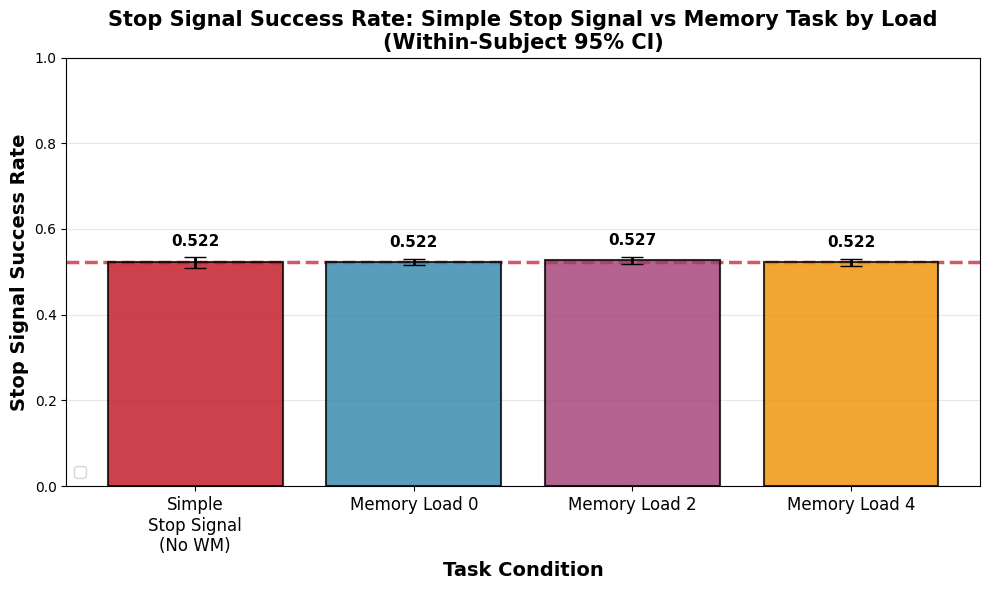


✓ Figure created successfully


In [14]:
# Prepare data for stop signal success rate by memory load
print("=== Stop Signal Success Rate: Simple Stop vs Memory Task by Load ===\n")

# Find participants with complete stop signal success rate data for both tasks
participants_both = list(set(metrics_data_stop['prolific_id']) & set(metrics_data_wm['prolific_id']))

# Filter for participants with complete data
stop_data = metrics_data_stop[metrics_data_stop['prolific_id'].isin(participants_both)]
stop_data = stop_data.dropna(subset=['stop_inhibition_success_rate'])

wm_data = metrics_data_wm[metrics_data_wm['prolific_id'].isin(participants_both)]
wm_data = wm_data.dropna(subset=[
    'dual_task_stop_wm2_inhibition_success_rate',
    'dual_task_stop_wm4_inhibition_success_rate',
    'dual_task_stop_wm6_inhibition_success_rate'
])

# Get overlapping participants with complete data
common_participants = list(set(stop_data['prolific_id']) & set(wm_data['prolific_id']))
stop_data_complete = stop_data[stop_data['prolific_id'].isin(common_participants)].set_index('prolific_id')
wm_data_complete = wm_data[wm_data['prolific_id'].isin(common_participants)].set_index('prolific_id')

print(f"Participants with complete stop signal success rate data for all conditions: {len(common_participants)}\n")

# Create data matrix for within-subject CI calculation
# Rows = participants, Columns = conditions
stop_success_matrix = pd.DataFrame({
    'Simple_Stop': stop_data_complete['stop_inhibition_success_rate'],
    'WM_Load_0': wm_data_complete['dual_task_stop_wm2_inhibition_success_rate'],
    'WM_Load_2': wm_data_complete['dual_task_stop_wm4_inhibition_success_rate'],
    'WM_Load_4': wm_data_complete['dual_task_stop_wm6_inhibition_success_rate']
})

# Calculate within-subject confidence intervals
all_cis = calculate_within_subject_ci(stop_success_matrix)

# Calculate means for each condition
all_means = np.array([
    stop_success_matrix['Simple_Stop'].mean(),
    stop_success_matrix['WM_Load_0'].mean(),
    stop_success_matrix['WM_Load_2'].mean(),
    stop_success_matrix['WM_Load_4'].mean()
])

# Store simple stop mean for reference line
simple_stop_mean = all_means[0]

# Print descriptive statistics
print("Descriptive Statistics:")
print(f"  Simple Stop Signal: M={all_means[0]:.3f}, SD={stop_success_matrix['Simple_Stop'].std():.3f}")
print(f"  WM Load 0: M={all_means[1]:.3f}, SD={stop_success_matrix['WM_Load_0'].std():.3f}")
print(f"  WM Load 2: M={all_means[2]:.3f}, SD={stop_success_matrix['WM_Load_2'].std():.3f}")
print(f"  WM Load 4: M={all_means[3]:.3f}, SD={stop_success_matrix['WM_Load_4'].std():.3f}")
print(f"\nWithin-subject 95% CI half-widths:")
print(f"  Simple Stop Signal: ±{all_cis[0]:.3f}")
print(f"  WM Load 0: ±{all_cis[1]:.3f}")
print(f"  WM Load 2: ±{all_cis[2]:.3f}")
print(f"  WM Load 4: ±{all_cis[3]:.3f}")

# Create the figure
fig, ax = plt.subplots(figsize=(10, 6))

# Set up bar positions and colors
conditions = ['Simple\nStop Signal\n(No WM)', 'Memory Load 0', 'Memory Load 2', 'Memory Load 4']
x_pos = np.arange(len(conditions))
colors = ['#C1121F', '#2E86AB', '#A23B72', '#F18F01']  # Red for baseline, then blue/purple/orange

# Create bar plot
bars = ax.bar(x_pos, all_means, yerr=all_cis, capsize=8,
              alpha=0.8, color=colors, edgecolor='black', linewidth=1.5,
              error_kw={'linewidth': 2, 'ecolor': 'black'})

# Add horizontal line for simple stop signal mean
ax.axhline(y=simple_stop_mean, color='#C1121F', linestyle='--', linewidth=2.5, 
           alpha=0.7, zorder=0)

# Customize the plot
ax.set_xlabel('Task Condition', fontsize=14, fontweight='bold')
ax.set_ylabel('Stop Signal Success Rate', fontsize=14, fontweight='bold')
ax.set_title('Stop Signal Success Rate: Simple Stop Signal vs Memory Task by Load\n(Within-Subject 95% CI)', 
             fontsize=15, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(conditions, fontsize=12)
ax.set_ylim([0, 1.0])

# Add grid for readability
ax.grid(True, alpha=0.3, axis='y')
ax.set_axisbelow(True)
ax.legend(fontsize=11, loc='lower left')

# Add value labels on bars
for i, (bar, mean, ci) in enumerate(zip(bars, all_means, all_cis)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + ci + 0.02,
            f'{mean:.3f}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

# Add note about within-subject CIs
#ax.text(0.98, 0.02, 'Error bars show within-subject 95% CIs\n(Cousineau, 2005; Morey, 2008)',
#        transform=ax.transAxes, fontsize=9, style='italic',
#        ha='right', va='bottom', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.tight_layout()
plt.show()

print("\n✓ Figure created successfully")


## 12. BIC (Bayesian Information Criterion) Model Comparison

Bayesian model comparison for memory load effects on stop signal performance, comparing simple stop signal task vs memory task conditions (0, 2, 4 items). Uses BIC to compare models with and without condition effects.

In [15]:
# === BIC (Bayesian Information Criterion) Model Comparison ===
# Compare models with/without condition effects on Stop Signal Success Rate and GO RT

print("="*70)
print("=== BIC MODEL COMPARISON: Memory Load Effects ===")
print("="*70)

def calculate_bic(residuals, n_params, n_obs):
    """
    Calculate BIC for a model given its residuals.
    BIC = n * ln(RSS/n) + k * ln(n)
    where RSS = sum of squared residuals, k = number of parameters, n = observations
    """
    rss = np.sum(residuals**2)
    bic = n_obs * np.log(rss / n_obs) + n_params * np.log(n_obs)
    return bic

def interpret_bic_difference(delta_bic):
    """
    Interpret BIC difference according to Kass & Raftery (1995) guidelines.
    Positive delta_bic means the second model (with effects) is better.
    """
    if delta_bic > 10:
        return "Very Strong evidence for condition effects"
    elif delta_bic > 6:
        return "Strong evidence for condition effects"
    elif delta_bic > 2:
        return "Positive evidence for condition effects"
    elif delta_bic > 0:
        return "Weak evidence for condition effects"
    elif delta_bic > -2:
        return "Weak evidence against condition effects"
    elif delta_bic > -6:
        return "Positive evidence against condition effects"
    elif delta_bic > -10:
        return "Strong evidence against condition effects"
    else:
        return "Very Strong evidence against condition effects"

def calculate_bf10(delta_bic):
    """
    Calculate BF10 (Bayes Factor favoring full model over null) from delta BIC.
    BF10 = exp(delta_bic / 2), where delta_bic = BIC_null - BIC_full
    Based on the BIC approximation to the Bayes Factor (Wagenmakers, 2007).
    BF10 > 1 means evidence for condition effects; BF10 < 1 means evidence against.
    """
    return np.exp(delta_bic / 2)

# === PREPARE DATA ===
# Find participants with complete data for both tasks
participants_both = list(set(metrics_data_stop['prolific_id']) & set(metrics_data_wm['prolific_id']))

# Filter for participants with complete stop signal success rate data
stop_data = metrics_data_stop[metrics_data_stop['prolific_id'].isin(participants_both)]
stop_data = stop_data.dropna(subset=['stop_inhibition_success_rate'])

wm_data = metrics_data_wm[metrics_data_wm['prolific_id'].isin(participants_both)]
wm_data = wm_data.dropna(subset=[
    'dual_task_stop_wm2_inhibition_success_rate',
    'dual_task_stop_wm4_inhibition_success_rate',
    'dual_task_stop_wm6_inhibition_success_rate'
])

# Get overlapping participants with complete data
common_participants = list(set(stop_data['prolific_id']) & set(wm_data['prolific_id']))
stop_data_complete = stop_data[stop_data['prolific_id'].isin(common_participants)].set_index('prolific_id')
wm_data_complete = wm_data[wm_data['prolific_id'].isin(common_participants)].set_index('prolific_id')

n_participants = len(common_participants)
print(f"\nParticipants with complete data: {n_participants}")

# ===============================================
# BIC ANALYSIS 1: STOP SIGNAL SUCCESS RATE
# ===============================================
print("\n" + "="*70)
print("BIC ANALYSIS 1: STOP SIGNAL SUCCESS RATE")
print("="*70)

# Create data array: each participant's success rate across 4 conditions
# Conditions: Simple Stop, WM0, WM2, WM4
success_rate_data = np.column_stack([
    stop_data_complete['stop_inhibition_success_rate'].values,
    wm_data_complete['dual_task_stop_wm2_inhibition_success_rate'].values,
    wm_data_complete['dual_task_stop_wm4_inhibition_success_rate'].values,
    wm_data_complete['dual_task_stop_wm6_inhibition_success_rate'].values
])

n_conditions = 4
n_obs = n_participants * n_conditions

# Model 1 (Null): No condition effects - predict grand mean for all
grand_mean_sr = np.mean(success_rate_data)
residuals_null_sr = success_rate_data.flatten() - grand_mean_sr
bic_null_sr = calculate_bic(residuals_null_sr, 1, n_obs)  # 1 parameter (grand mean)

# Model 2 (Full): Condition effects - predict each condition's mean
condition_means_sr = np.mean(success_rate_data, axis=0)
residuals_full_sr = (success_rate_data - condition_means_sr).flatten()
bic_full_sr = calculate_bic(residuals_full_sr, n_conditions, n_obs)  # 4 parameters (4 condition means)

delta_bic_sr = bic_null_sr - bic_full_sr  # Positive = full model better
bf10_sr = calculate_bf10(delta_bic_sr)

print(f"\nCondition means (Stop Signal Success Rate):")
print(f"  Simple Stop:  {condition_means_sr[0]:.4f}")
print(f"  WM Load 0:    {condition_means_sr[1]:.4f}")
print(f"  WM Load 2:    {condition_means_sr[2]:.4f}")
print(f"  WM Load 4:    {condition_means_sr[3]:.4f}")
print(f"  Grand Mean:   {grand_mean_sr:.4f}")

print(f"\nBIC Model Comparison:")
print(f"  Null Model (no condition effects):  BIC = {bic_null_sr:.2f}")
print(f"  Full Model (condition effects):     BIC = {bic_full_sr:.2f}")
print(f"  Delta BIC (Null - Full):            {delta_bic_sr:.2f}")
print(f"  BF10 (Full vs Null):                {bf10_sr:.4f}")
print(f"\n  Interpretation: {interpret_bic_difference(delta_bic_sr)}")

# ===============================================
# BIC ANALYSIS 2: GO TRIAL REACTION TIME
# ===============================================
print("\n" + "="*70)
print("BIC ANALYSIS 2: GO TRIAL REACTION TIME")
print("="*70)

# Get GO RT data
# Filter for participants with complete GO RT data
stop_data_rt = metrics_data_stop[metrics_data_stop['prolific_id'].isin(participants_both)]
stop_data_rt = stop_data_rt.dropna(subset=['go_mean_rt'])

wm_data_rt = metrics_data_wm[metrics_data_wm['prolific_id'].isin(participants_both)]
wm_data_rt = wm_data_rt.dropna(subset=[
    'dual_task_go_wm2_mean_rt',
    'dual_task_go_wm4_mean_rt',
    'dual_task_go_wm6_mean_rt'
])

# Get overlapping participants with complete RT data
common_participants_rt = list(set(stop_data_rt['prolific_id']) & set(wm_data_rt['prolific_id']))
stop_data_rt_complete = stop_data_rt[stop_data_rt['prolific_id'].isin(common_participants_rt)].set_index('prolific_id')
wm_data_rt_complete = wm_data_rt[wm_data_rt['prolific_id'].isin(common_participants_rt)].set_index('prolific_id')

n_participants_rt = len(common_participants_rt)
print(f"\nParticipants with complete GO RT data: {n_participants_rt}")

# Create data array
go_rt_data = np.column_stack([
    stop_data_rt_complete['go_mean_rt'].values,
    wm_data_rt_complete['dual_task_go_wm2_mean_rt'].values,
    wm_data_rt_complete['dual_task_go_wm4_mean_rt'].values,
    wm_data_rt_complete['dual_task_go_wm6_mean_rt'].values
])

n_obs_rt = n_participants_rt * n_conditions

# Model 1 (Null): No condition effects
grand_mean_rt = np.mean(go_rt_data)
residuals_null_rt = go_rt_data.flatten() - grand_mean_rt
bic_null_rt = calculate_bic(residuals_null_rt, 1, n_obs_rt)

# Model 2 (Full): Condition effects
condition_means_rt = np.mean(go_rt_data, axis=0)
residuals_full_rt = (go_rt_data - condition_means_rt).flatten()
bic_full_rt = calculate_bic(residuals_full_rt, n_conditions, n_obs_rt)

delta_bic_rt = bic_null_rt - bic_full_rt
bf10_rt = calculate_bf10(delta_bic_rt)

print(f"\nCondition means (GO RT in ms):")
print(f"  Simple Stop:  {condition_means_rt[0]:.1f}")
print(f"  WM Load 0:    {condition_means_rt[1]:.1f}")
print(f"  WM Load 2:    {condition_means_rt[2]:.1f}")
print(f"  WM Load 4:    {condition_means_rt[3]:.1f}")
print(f"  Grand Mean:   {grand_mean_rt:.1f}")

print(f"\nBIC Model Comparison:")
print(f"  Null Model (no condition effects):  BIC = {bic_null_rt:.2f}")
print(f"  Full Model (condition effects):     BIC = {bic_full_rt:.2f}")
print(f"  Delta BIC (Null - Full):            {delta_bic_rt:.2f}")
print(f"  BF10 (Full vs Null):                {bf10_rt:.4f}")
print(f"\n  Interpretation: {interpret_bic_difference(delta_bic_rt)}")

# ===============================================
# BIC ANALYSIS 3: SSRT (Stop Signal Reaction Time)
# ===============================================
print("\n" + "="*70)
print("BIC ANALYSIS 3: SSRT (STOP SIGNAL REACTION TIME)")
print("="*70)

# Get SSRT data
# Filter for participants with complete SSRT data
stop_data_ssrt = metrics_data_stop[metrics_data_stop['prolific_id'].isin(participants_both)]
stop_data_ssrt = stop_data_ssrt.dropna(subset=['SSRT'])

wm_data_ssrt = metrics_data_wm[metrics_data_wm['prolific_id'].isin(participants_both)]
wm_data_ssrt = wm_data_ssrt.dropna(subset=[
    'SSRT_wm2',
    'SSRT_wm4',
    'SSRT_wm6'
])

# Get overlapping participants with complete SSRT data
common_participants_ssrt = list(set(stop_data_ssrt['prolific_id']) & set(wm_data_ssrt['prolific_id']))
stop_data_ssrt_complete = stop_data_ssrt[stop_data_ssrt['prolific_id'].isin(common_participants_ssrt)].set_index('prolific_id')
wm_data_ssrt_complete = wm_data_ssrt[wm_data_ssrt['prolific_id'].isin(common_participants_ssrt)].set_index('prolific_id')

n_participants_ssrt = len(common_participants_ssrt)
print(f"\nParticipants with complete SSRT data: {n_participants_ssrt}")

# Create data array
ssrt_data = np.column_stack([
    stop_data_ssrt_complete['SSRT'].values,
    wm_data_ssrt_complete['SSRT_wm2'].values,
    wm_data_ssrt_complete['SSRT_wm4'].values,
    wm_data_ssrt_complete['SSRT_wm6'].values
])

n_obs_ssrt = n_participants_ssrt * n_conditions

# Model 1 (Null): No condition effects
grand_mean_ssrt = np.mean(ssrt_data)
residuals_null_ssrt = ssrt_data.flatten() - grand_mean_ssrt
bic_null_ssrt = calculate_bic(residuals_null_ssrt, 1, n_obs_ssrt)

# Model 2 (Full): Condition effects
condition_means_ssrt = np.mean(ssrt_data, axis=0)
residuals_full_ssrt = (ssrt_data - condition_means_ssrt).flatten()
bic_full_ssrt = calculate_bic(residuals_full_ssrt, n_conditions, n_obs_ssrt)

delta_bic_ssrt = bic_null_ssrt - bic_full_ssrt
bf10_ssrt = calculate_bf10(delta_bic_ssrt)

print(f"\nCondition means (SSRT in ms):")
print(f"  Simple Stop:  {condition_means_ssrt[0]:.1f}")
print(f"  WM Load 0:    {condition_means_ssrt[1]:.1f}")
print(f"  WM Load 2:    {condition_means_ssrt[2]:.1f}")
print(f"  WM Load 4:    {condition_means_ssrt[3]:.1f}")
print(f"  Grand Mean:   {grand_mean_ssrt:.1f}")

print(f"\nBIC Model Comparison:")
print(f"  Null Model (no condition effects):  BIC = {bic_null_ssrt:.2f}")
print(f"  Full Model (condition effects):     BIC = {bic_full_ssrt:.2f}")
print(f"  Delta BIC (Null - Full):            {delta_bic_ssrt:.2f}")
print(f"  BF10 (Full vs Null):                {bf10_ssrt:.4f}")
print(f"\n  Interpretation: {interpret_bic_difference(delta_bic_ssrt)}")

# ===============================================
# SUMMARY TABLE
# ===============================================
print("\n" + "="*70)
print("SUMMARY: BIC Model Comparison Results")
print("="*70)
print(f"\n{'Measure':<30} {'BIC Null':>12} {'BIC Full':>12} {'Delta BIC':>12} {'BF10':>12} {'Evidence':<35}")
print("-"*113)
print(f"{'Stop Signal Success Rate':<30} {bic_null_sr:>12.2f} {bic_full_sr:>12.2f} {delta_bic_sr:>12.2f} {bf10_sr:>12.4f} {interpret_bic_difference(delta_bic_sr):<35}")
print(f"{'GO Reaction Time':<30} {bic_null_rt:>12.2f} {bic_full_rt:>12.2f} {delta_bic_rt:>12.2f} {bf10_rt:>12.4f} {interpret_bic_difference(delta_bic_rt):<35}")
print(f"{'SSRT':<30} {bic_null_ssrt:>12.2f} {bic_full_ssrt:>12.2f} {delta_bic_ssrt:>12.2f} {bf10_ssrt:>12.4f} {interpret_bic_difference(delta_bic_ssrt):<35}")

print("\n" + "="*70)
print("Note: Positive Delta BIC indicates evidence FOR condition effects")
print("      (the full model with separate condition means is better)")
print("      BF10 = Bayes Factor favoring Full model over Null")
print("      BF10 > 1: evidence for condition effects")
print("      BF10 < 1: evidence against (1/BF10 = BF in favor of null)")
print("      Interpretation based on Kass & Raftery (1995) guidelines:")
print("      0-2: Weak, 2-6: Positive, 6-10: Strong, >10: Very Strong")
print("      BF approximation from BIC per Wagenmakers (2007)")
print("="*70)

=== BIC MODEL COMPARISON: Memory Load Effects ===

Participants with complete data: 38

BIC ANALYSIS 1: STOP SIGNAL SUCCESS RATE

Condition means (Stop Signal Success Rate):
  Simple Stop:  0.5219
  WM Load 0:    0.5225
  WM Load 2:    0.5269
  WM Load 4:    0.5219
  Grand Mean:   0.5233

BIC Model Comparison:
  Null Model (no condition effects):  BIC = -1002.55
  Full Model (condition effects):     BIC = -987.97
  Delta BIC (Null - Full):            -14.58
  BF10 (Full vs Null):                0.0007

  Interpretation: Very Strong evidence against condition effects

BIC ANALYSIS 2: GO TRIAL REACTION TIME

Participants with complete GO RT data: 38

Condition means (GO RT in ms):
  Simple Stop:  658.7
  WM Load 0:    714.8
  WM Load 2:    703.5
  WM Load 4:    724.5
  Grand Mean:   700.4

BIC Model Comparison:
  Null Model (no condition effects):  BIC = 1530.18
  Full Model (condition effects):     BIC = 1540.96
  Delta BIC (Null - Full):            -10.79
  BF10 (Full vs Null):        

## 13. Pairwise T-Tests: SSRT Across Conditions

Paired t-tests comparing SSRT between each pair of conditions (Simple Stop, WM Load 0, WM Load 2, WM Load 4).

In [16]:
# === PAIRWISE PAIRED T-TESTS: SSRT ACROSS CONDITIONS ===
from itertools import combinations
from scipy.stats import ttest_rel

print("="*80)
print("=== PAIRWISE PAIRED T-TESTS: SSRT ACROSS CONDITIONS ===")
print("="*80)

# === PREPARE DATA ===
# Find participants with complete data for both tasks
participants_both = list(set(metrics_data_stop['prolific_id']) & set(metrics_data_wm['prolific_id']))

# Filter for participants with complete SSRT data
stop_data_ssrt = metrics_data_stop[metrics_data_stop['prolific_id'].isin(participants_both)]
stop_data_ssrt = stop_data_ssrt.dropna(subset=['SSRT'])

wm_data_ssrt = metrics_data_wm[metrics_data_wm['prolific_id'].isin(participants_both)]
wm_data_ssrt = wm_data_ssrt.dropna(subset=['SSRT_wm2', 'SSRT_wm4', 'SSRT_wm6'])

# Get overlapping participants with complete SSRT data
common_participants_ssrt = list(set(stop_data_ssrt['prolific_id']) & set(wm_data_ssrt['prolific_id']))
stop_data_ssrt_complete = stop_data_ssrt[stop_data_ssrt['prolific_id'].isin(common_participants_ssrt)].set_index('prolific_id')
wm_data_ssrt_complete = wm_data_ssrt[wm_data_ssrt['prolific_id'].isin(common_participants_ssrt)].set_index('prolific_id')

# Align indices to ensure paired data
wm_data_ssrt_complete = wm_data_ssrt_complete.loc[stop_data_ssrt_complete.index]

n_participants = len(common_participants_ssrt)
print(f"\nParticipants with complete SSRT data: {n_participants}")

# Create dictionary of SSRT data by condition
ssrt_by_condition = {
    'Simple Stop': stop_data_ssrt_complete['SSRT'].values,
    'WM Load 0': wm_data_ssrt_complete['SSRT_wm2'].values,
    'WM Load 2': wm_data_ssrt_complete['SSRT_wm4'].values,
    'WM Load 4': wm_data_ssrt_complete['SSRT_wm6'].values
}

# Print descriptive statistics
print("\n" + "-"*80)
print("Descriptive Statistics (SSRT in ms):")
print("-"*80)
for condition, data in ssrt_by_condition.items():
    print(f"  {condition:<15}: M = {np.mean(data):7.2f}, SD = {np.std(data, ddof=1):7.2f}")

# === PAIRWISE T-TESTS ===
print("\n" + "="*80)
print("Pairwise Paired T-Tests")
print("="*80)

conditions = list(ssrt_by_condition.keys())
n_comparisons = len(list(combinations(conditions, 2)))
bonferroni_alpha = 0.05 / n_comparisons

print(f"\nNumber of comparisons: {n_comparisons}")
print(f"Bonferroni-corrected alpha: {bonferroni_alpha:.4f}")

print(f"\n{'Comparison':<35} {'t-stat':>10} {'p-value':>12} {'Mean Diff':>12} {'Cohens d':>12} {'Sig':>8}" )
print("-"*91)

results = []
for cond1, cond2 in combinations(conditions, 2):
    data1 = ssrt_by_condition[cond1]
    data2 = ssrt_by_condition[cond2]
    
    # Paired t-test
    t_stat, p_value = ttest_rel(data1, data2)
    
    # Effect size (Cohen's d for paired samples)
    diff = data1 - data2
    mean_diff = np.mean(diff)
    cohens_d = mean_diff / np.std(diff, ddof=1)
    
    # Significance markers
    if p_value < 0.001:
        sig = "***"
    elif p_value < 0.01:
        sig = "**"
    elif p_value < 0.05:
        sig = "*"
    elif p_value < bonferroni_alpha:
        sig = "†"  # Bonferroni significant only
    else:
        sig = ""
    
    comparison = f"{cond1} vs {cond2}"
    print(f"{comparison:<35} {t_stat:>10.3f} {p_value:>12.6f} {mean_diff:>12.2f} {cohens_d:>12.3f} {sig:>8}")
    
    results.append({
        'comparison': comparison,
        't_stat': t_stat,
        'p_value': p_value,
        'mean_diff': mean_diff,
        'cohens_d': cohens_d,
        'sig': sig
    })

print("-"*91)
print("\nSignificance: *** p < .001, ** p < .01, * p < .05")
print(f"              † Bonferroni-corrected (p < {bonferroni_alpha:.4f})")

# === SUMMARY OF SIGNIFICANT EFFECTS ===
print("\n" + "="*80)
print("Summary of Significant Effects (uncorrected p < .05)")
print("="*80)
sig_results = [r for r in results if r['p_value'] < 0.05]
if sig_results:
    for r in sig_results:
        direction = ">" if r['mean_diff'] > 0 else "<"
        conds = r['comparison'].split(' vs ')
        print(f"  {conds[0]} {direction} {conds[1]}: t({n_participants-1}) = {r['t_stat']:.3f}, p = {r['p_value']:.4f}, d = {r['cohens_d']:.3f}")
else:
    print("  No significant pairwise differences found.")

# === BONFERRONI-CORRECTED SUMMARY ===
print("\n" + "="*80)
print(f"Summary of Bonferroni-Corrected Significant Effects (p < {bonferroni_alpha:.4f})")
print("="*80)
bonf_results = [r for r in results if r['p_value'] < bonferroni_alpha]
if bonf_results:
    for r in bonf_results:
        direction = ">" if r['mean_diff'] > 0 else "<"
        conds = r['comparison'].split(' vs ')
        print(f"  {conds[0]} {direction} {conds[1]}: t({n_participants-1}) = {r['t_stat']:.3f}, p = {r['p_value']:.4f}, d = {r['cohens_d']:.3f}")
else:
    print("  No significant pairwise differences survive Bonferroni correction.")

=== PAIRWISE PAIRED T-TESTS: SSRT ACROSS CONDITIONS ===

Participants with complete SSRT data: 38

--------------------------------------------------------------------------------
Descriptive Statistics (SSRT in ms):
--------------------------------------------------------------------------------
  Simple Stop    : M =  243.64, SD =   78.79
  WM Load 0      : M =  260.05, SD =   58.66
  WM Load 2      : M =  254.45, SD =   47.64
  WM Load 4      : M =  251.48, SD =   48.97

Pairwise Paired T-Tests

Number of comparisons: 6
Bonferroni-corrected alpha: 0.0083

Comparison                              t-stat      p-value    Mean Diff    Cohen\s d      Sig
-------------------------------------------------------------------------------------------
Simple Stop vs WM Load 0                -1.698     0.097903       -16.42       -0.275         
Simple Stop vs WM Load 2                -0.958     0.344386       -10.81       -0.155         
Simple Stop vs WM Load 4                -0.487     0.62909

## 14. Repeated Measures ANOVA: Probe Accuracy by Memory Load

Proper repeated measures ANOVA with:
- Mauchly's test of sphericity
- Greenhouse-Geisser correction (if sphericity violated)
- Post-hoc pairwise comparisons with Bonferroni correction

One-way repeated measures ANOVA testing the effect of working memory load (0, 2, 4 items) on probe (memory recognition) accuracy.

In [17]:
# === REPEATED MEASURES ANOVA: PROBE ACCURACY BY MEMORY LOAD ===
import pingouin as pg

print("="*70)
print("REPEATED MEASURES ANOVA: Probe Accuracy by Memory Load")
print("="*70)

# Prepare data for ANOVA - need participants with complete data for all conditions
complete_participants_probe = metrics_data_wm.dropna(subset=[
    'probe_wm2_response_accuracy',
    'probe_wm4_response_accuracy',
    'probe_wm6_response_accuracy'
])

n_participants = len(complete_participants_probe)
print(f"\nParticipants with complete probe accuracy data for all conditions: {n_participants}")

# Create long-format dataframe for pingouin
df_long_probe = pd.DataFrame({
    'subject': list(range(n_participants)) * 3,
    'wm_load': ['0'] * n_participants + ['2'] * n_participants + ['4'] * n_participants,
    'accuracy': np.concatenate([
        complete_participants_probe['probe_wm2_response_accuracy'].values,
        complete_participants_probe['probe_wm4_response_accuracy'].values,
        complete_participants_probe['probe_wm6_response_accuracy'].values
    ])
})

# === DESCRIPTIVE STATISTICS ===
print("\n" + "-"*70)
print("Descriptive Statistics:")
print("-"*70)
for load in ['0', '2', '4']:
    data = df_long_probe[df_long_probe['wm_load'] == load]['accuracy']
    print(f"  WM Load {load}: M = {data.mean():.4f}, SD = {data.std():.4f}")

# === REPEATED MEASURES ANOVA ===
print("\n" + "="*70)
print("Repeated Measures ANOVA Results:")
print("="*70)

aov_probe = pg.rm_anova(data=df_long_probe, dv='accuracy', within='wm_load', subject='subject', detailed=True, correction=True)
print("\n")
print(aov_probe.to_string())

# Sphericity test
spher_probe = pg.sphericity(data=df_long_probe, dv='accuracy', within='wm_load', subject='subject')
print(f"\nMauchly's Test of Sphericity:")
print(f"  W = {spher_probe.W:.4f}, p = {spher_probe.pval:.4f}")

# Get the relevant p-value based on sphericity
if spher_probe.pval < 0.05:
    print("  ⚠️  Sphericity VIOLATED - use Greenhouse-Geisser corrected values")
    print(f"  Greenhouse-Geisser epsilon: {aov_probe['eps'].values[0]:.4f}")
    gg_p = aov_probe['p-GG-corr'].values[0]
    print(f"  GG-corrected p-value: {gg_p:.6f}")
    p_value = gg_p
else:
    print("  ✓ Sphericity assumption met")
    p_value = aov_probe['p-unc'].values[0]

# Effect size interpretation
ng2 = aov_probe['ng2'].values[0]
# Calculate partial eta-squared from SS: np2 = SS_effect / (SS_effect + SS_error)
ss_effect = aov_probe['SS'].values[0]
ss_error = aov_probe['SS'].values[1]
np2 = ss_effect / (ss_effect + ss_error) if (ss_effect + ss_error) > 0 else 0

if np2 < 0.01:
    effect_interp = "negligible"
elif np2 < 0.06:
    effect_interp = "small"
elif np2 < 0.14:
    effect_interp = "medium"
else:
    effect_interp = "large"

print(f"\nEffect Size:")
print(f"  Partial η² = {np2:.4f} ({effect_interp})")
print(f"  Generalized η² = {ng2:.4f}")

# === POST-HOC PAIRWISE COMPARISONS ===
print("\n" + "="*70)
print("Post-Hoc Pairwise Comparisons (Paired T-Tests with Bonferroni):")
print("="*70)

posthoc = pg.pairwise_tests(data=df_long_probe, dv='accuracy', within='wm_load', subject='subject',
                            padjust='bonf', effsize='cohen')
print("\n")
print(posthoc[['Contrast', 'A', 'B', 'T', 'dof', 'p-unc', 'p-corr', 'cohen']].to_string())

# === SUMMARY ===
print("\n" + "="*70)
print("Summary:")
print("="*70)
f_stat = aov_probe['F'].values[0]
df1 = int(aov_probe['DF'].values[0])
df2 = int(aov_probe['DF'].values[1])

if p_value < 0.05:
    print(f"  There IS a significant effect of memory load on probe accuracy,")
    print(f"  F({df1}, {df2}) = {f_stat:.3f}, p = {p_value:.4f}, partial η² = {np2:.3f} ({effect_interp})")
else:
    print(f"  There is NO significant effect of memory load on probe accuracy,")
    print(f"  F({df1}, {df2}) = {f_stat:.3f}, p = {p_value:.4f}, partial η² = {np2:.3f} ({effect_interp})")

REPEATED MEASURES ANOVA: Probe Accuracy by Memory Load

Participants with complete probe accuracy data for all conditions: 38

----------------------------------------------------------------------
Descriptive Statistics:
----------------------------------------------------------------------
  WM Load 0: M = 0.9519, SD = 0.0786
  WM Load 2: M = 0.9039, SD = 0.0897
  WM Load 4: M = 0.8861, SD = 0.1005

Repeated Measures ANOVA Results:


    Source        SS  DF        MS          F     p-unc       ng2      eps
0  wm_load  0.088065   2  0.044033  12.396294  0.000023  0.089188  0.63417
1    Error  0.262854  74  0.003552        NaN       NaN       NaN      NaN

Mauchly's Test of Sphericity:
  W = 640.0057, p = 1.0000
  ✓ Sphericity assumption met

Effect Size:
  Partial η² = 0.2510 (large)
  Generalized η² = 0.0892

Post-Hoc Pairwise Comparisons (Paired T-Tests with Bonferroni):


  Contrast  A  B         T   dof     p-unc    p-corr     cohen
0  wm_load  0  2  3.027316  37.0  0.004475  0.0

## 15. Probe Accuracy by Stop Signal Outcome

Analysis of probe accuracy conditional on stop signal outcome:
- **Successful Stop**: Trials where a stop signal was presented and the participant successfully inhibited their response
- **Failed Stop**: Trials where a stop signal was presented but the participant failed to inhibit
- **Go Trials**: Trials with no stop signal

This examines whether successful response inhibition is associated with better or worse memory performance.

PROBE ACCURACY BY STOP SIGNAL OUTCOME

--- OVERALL (collapsed across WM load) ---

Successful Stop: M = 0.911, SD = 0.089, n = 38
Failed Stop:     M = 0.911, SD = 0.080, n = 38
Go Trials:       M = 0.915, SD = 0.077, n = 38

Paired t-tests (overall):
  Successful vs Failed: t = 0.017, p = 0.9863, Cohen's d = 0.003
  Successful vs Go:     t = -0.654, p = 0.5172, Cohen's d = -0.106
  Failed vs Go:         t = -0.465, p = 0.6449, Cohen's d = -0.075

BY MEMORY LOAD LEVEL

--- WM Load = 0 ---

Successful Stop: M = 0.943, SD = 0.104, n_subj = 38, avg_trials = 25.1
Failed Stop:     M = 0.950, SD = 0.092, n_subj = 38, avg_trials = 22.9
Go Trials:       M = 0.955, SD = 0.077, n_subj = 38, avg_trials = 96.0

  Successful vs Failed: t = -0.651, p = 0.5194, Cohen's d = -0.106

--- WM Load = 2 ---

Successful Stop: M = 0.890, SD = 0.117, n_subj = 38, avg_trials = 25.3
Failed Stop:     M = 0.904, SD = 0.087, n_subj = 38, avg_trials = 22.7
Go Trials:       M = 0.907, SD = 0.091, n_subj = 38, avg_tria

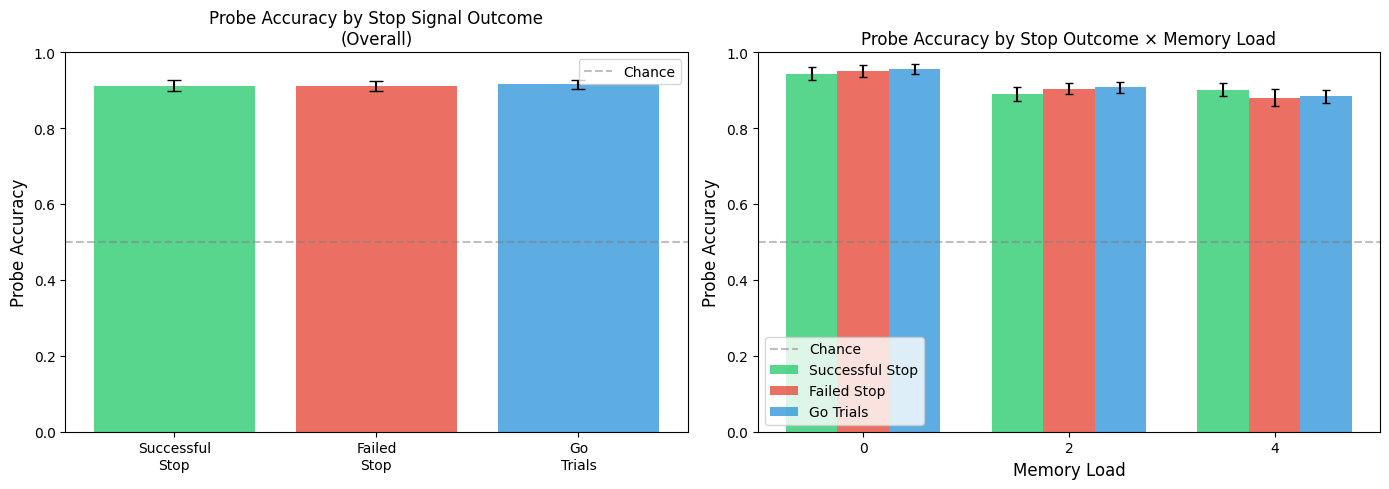


Note: Error bars represent standard error of the mean (SEM).


In [18]:
# === PROBE ACCURACY BY STOP SIGNAL OUTCOME ===
# Reload data to get new columns
metrics_data_wm = pd.read_csv('../data/results/post_qc_stop_signal_wm_metrics.csv')

print("=" * 70)
print("PROBE ACCURACY BY STOP SIGNAL OUTCOME")
print("=" * 70)

# --- Overall Analysis (collapsed across WM load) ---
print("\n--- OVERALL (collapsed across WM load) ---\n")

# Extract overall metrics
overall_successful = metrics_data_wm['probe_accuracy_on_successful_stop'].dropna()
overall_failed = metrics_data_wm['probe_accuracy_on_failed_stop'].dropna()
overall_go = metrics_data_wm['probe_accuracy_on_go_trials'].dropna()

print(f"Successful Stop: M = {overall_successful.mean():.3f}, SD = {overall_successful.std():.3f}, n = {len(overall_successful)}")
print(f"Failed Stop:     M = {overall_failed.mean():.3f}, SD = {overall_failed.std():.3f}, n = {len(overall_failed)}")
print(f"Go Trials:       M = {overall_go.mean():.3f}, SD = {overall_go.std():.3f}, n = {len(overall_go)}")

# Paired t-tests for overall comparison
from scipy.stats import ttest_rel
print("\nPaired t-tests (overall):")
# Successful vs Failed
common_idx = overall_successful.index.intersection(overall_failed.index)
if len(common_idx) > 2:
    t, p = ttest_rel(overall_successful.loc[common_idx], overall_failed.loc[common_idx])
    diff = overall_successful.loc[common_idx] - overall_failed.loc[common_idx]
    d = diff.mean() / diff.std() if diff.std() > 0 else np.nan
    print(f"  Successful vs Failed: t = {t:.3f}, p = {p:.4f}, Cohen's d = {d:.3f}")

# Successful vs Go
common_idx = overall_successful.index.intersection(overall_go.index)
if len(common_idx) > 2:
    t, p = ttest_rel(overall_successful.loc[common_idx], overall_go.loc[common_idx])
    diff = overall_successful.loc[common_idx] - overall_go.loc[common_idx]
    d = diff.mean() / diff.std() if diff.std() > 0 else np.nan
    print(f"  Successful vs Go:     t = {t:.3f}, p = {p:.4f}, Cohen's d = {d:.3f}")

# Failed vs Go  
common_idx = overall_failed.index.intersection(overall_go.index)
if len(common_idx) > 2:
    t, p = ttest_rel(overall_failed.loc[common_idx], overall_go.loc[common_idx])
    diff = overall_failed.loc[common_idx] - overall_go.loc[common_idx]
    d = diff.mean() / diff.std() if diff.std() > 0 else np.nan
    print(f"  Failed vs Go:         t = {t:.3f}, p = {p:.4f}, Cohen's d = {d:.3f}")

# --- By WM Load Level ---
print("\n" + "=" * 70)
print("BY MEMORY LOAD LEVEL")
print("=" * 70)

wm_loads = [2, 4, 6]
results_by_load = {}

for wm_load in wm_loads:
    print(f"\n--- WM Load = {wm_load} ---\n")
    
    successful = metrics_data_wm[f'probe_wm{wm_load}_accuracy_on_successful_stop'].dropna()
    failed = metrics_data_wm[f'probe_wm{wm_load}_accuracy_on_failed_stop'].dropna()
    go = metrics_data_wm[f'probe_wm{wm_load}_accuracy_on_go_trials'].dropna()
    
    n_successful = metrics_data_wm[f'probe_wm{wm_load}_n_successful_stop_trials'].dropna()
    n_failed = metrics_data_wm[f'probe_wm{wm_load}_n_failed_stop_trials'].dropna()
    n_go = metrics_data_wm[f'probe_wm{wm_load}_n_go_trials'].dropna()
    
    print(f"Successful Stop: M = {successful.mean():.3f}, SD = {successful.std():.3f}, n_subj = {len(successful)}, avg_trials = {n_successful.mean():.1f}")
    print(f"Failed Stop:     M = {failed.mean():.3f}, SD = {failed.std():.3f}, n_subj = {len(failed)}, avg_trials = {n_failed.mean():.1f}")
    print(f"Go Trials:       M = {go.mean():.3f}, SD = {go.std():.3f}, n_subj = {len(go)}, avg_trials = {n_go.mean():.1f}")
    
    results_by_load[wm_load] = {
        'successful': {'mean': successful.mean(), 'std': successful.std(), 'n': len(successful)},
        'failed': {'mean': failed.mean(), 'std': failed.std(), 'n': len(failed)},
        'go': {'mean': go.mean(), 'std': go.std(), 'n': len(go)}
    }
    
    # Paired t-test: Successful vs Failed
    common_idx = successful.index.intersection(failed.index)
    if len(common_idx) > 2:
        t, p = ttest_rel(successful.loc[common_idx], failed.loc[common_idx])
        diff = successful.loc[common_idx] - failed.loc[common_idx]
        d = diff.mean() / diff.std() if diff.std() > 0 else np.nan
        print(f"\n  Successful vs Failed: t = {t:.3f}, p = {p:.4f}, Cohen's d = {d:.3f}")

# --- Visualization ---
print("\n" + "=" * 70)
print("VISUALIZATION")
print("=" * 70)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Overall comparison (bar chart)
ax1 = axes[0]
conditions = ['Successful\nStop', 'Failed\nStop', 'Go\nTrials']
means = [overall_successful.mean(), overall_failed.mean(), overall_go.mean()]
stds = [overall_successful.std(), overall_failed.std(), overall_go.std()]
sems = [s/np.sqrt(n) for s, n in zip(stds, [len(overall_successful), len(overall_failed), len(overall_go)])]

bars = ax1.bar(conditions, means, yerr=sems, capsize=5, color=['#2E86AB', '#A23B72', '#F18F01'], alpha=0.8)
ax1.set_ylabel('Probe Accuracy', fontsize=12)
ax1.set_title('Probe Accuracy by Stop Signal Outcome\n(Overall)', fontsize=12)
ax1.set_ylim(0, 1)
ax1.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Chance')
ax1.legend()

# Add significance indicators
y_max = max(means) + max(sems) + 0.05
# (Could add significance bars here if desired)

# Plot 2: By WM load (grouped bar chart)
ax2 = axes[1]
x = np.arange(len(wm_loads))
width = 0.25

successful_means = [results_by_load[wm]['successful']['mean'] for wm in wm_loads]
failed_means = [results_by_load[wm]['failed']['mean'] for wm in wm_loads]
go_means = [results_by_load[wm]['go']['mean'] for wm in wm_loads]

successful_sems = [results_by_load[wm]['successful']['std']/np.sqrt(results_by_load[wm]['successful']['n']) for wm in wm_loads]
failed_sems = [results_by_load[wm]['failed']['std']/np.sqrt(results_by_load[wm]['failed']['n']) for wm in wm_loads]
go_sems = [results_by_load[wm]['go']['std']/np.sqrt(results_by_load[wm]['go']['n']) for wm in wm_loads]

bars1 = ax2.bar(x - width, successful_means, width, yerr=successful_sems, capsize=3, 
                label='Successful Stop', color='#2E86AB', alpha=0.8)
bars2 = ax2.bar(x, failed_means, width, yerr=failed_sems, capsize=3,
                label='Failed Stop', color='#A23B72', alpha=0.8)
bars3 = ax2.bar(x + width, go_means, width, yerr=go_sems, capsize=3,
                label='Go Trials', color='#F18F01', alpha=0.8)

ax2.set_xlabel('Memory Load', fontsize=12)
ax2.set_ylabel('Probe Accuracy', fontsize=12)
ax2.set_title('Probe Accuracy by Stop Outcome × Memory Load', fontsize=12)
ax2.set_xticks(x)
ax2.set_xticklabels(['0', '2', '4'])
ax2.set_ylim(0, 1)
ax2.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Chance')
ax2.legend(loc='lower left')

plt.tight_layout()
plt.show()

print("\nNote: Error bars represent standard error of the mean (SEM).")

## 16. Summary Table for Manuscript

A comprehensive summary of all statistical analyses for the results write-up.

In [19]:
# === SUMMARY TABLE FOR MANUSCRIPT ===
import pingouin as pg
from scipy.stats import ttest_rel

# Reload data to ensure we have latest
metrics_data_wm = pd.read_csv('../data/results/post_qc_stop_signal_wm_metrics.csv')
metrics_data_stop = pd.read_csv('../data/results/post_qc_stop_signal_metrics.csv')

print("=" * 90)
print("STATISTICAL SUMMARY TABLE FOR MANUSCRIPT")
print("=" * 90)

results = []

# ============================================================================
# 1. GO TRIAL ACCURACY - RM ANOVA
# ============================================================================
complete_go = metrics_data_wm.dropna(subset=[
    'dual_task_go_wm2_choice_accuracy', 'dual_task_go_wm4_choice_accuracy', 'dual_task_go_wm6_choice_accuracy'
])
n = len(complete_go)

df_acc = pd.DataFrame({
    'subject': list(range(n)) * 3,
    'wm_load': ['0'] * n + ['2'] * n + ['4'] * n,
    'accuracy': np.concatenate([
        complete_go['dual_task_go_wm2_choice_accuracy'].values,
        complete_go['dual_task_go_wm4_choice_accuracy'].values,
        complete_go['dual_task_go_wm6_choice_accuracy'].values
    ])
})

aov_acc = pg.rm_anova(data=df_acc, dv='accuracy', within='wm_load', subject='subject', detailed=True, correction=True)
spher_acc = pg.sphericity(data=df_acc, dv='accuracy', within='wm_load', subject='subject')
p_acc = aov_acc['p-GG-corr'].values[0] if spher_acc.pval < 0.05 else aov_acc['p-unc'].values[0]
np2_acc = aov_acc['SS'].values[0] / (aov_acc['SS'].values[0] + aov_acc['SS'].values[1])

mse_acc = aov_acc['MS'].values[1]  # MS for Error row
results.append({
    'Analysis': 'Go Trial Accuracy × WM Load',
    'Test': 'RM-ANOVA',
    'F': f"{aov_acc['F'].values[0]:.2f}",
    'df': f"({int(aov_acc['DF'].values[0])}, {int(aov_acc['DF'].values[1])})",
    'MSE': f"{mse_acc:.4f}",
    'p': f"{p_acc:.4f}",
    'Effect Size': f"η²p = {np2_acc:.3f}",
    'Sphericity (W, p)': f"W={spher_acc.W:.3f}, p={spher_acc.pval:.3f}",
    'n': n
})

# ============================================================================
# 2. GO TRIAL RT - RM ANOVA
# ============================================================================
complete_rt = metrics_data_wm.dropna(subset=[
    'dual_task_go_wm2_mean_rt', 'dual_task_go_wm4_mean_rt', 'dual_task_go_wm6_mean_rt'
])
n = len(complete_rt)

df_rt = pd.DataFrame({
    'subject': list(range(n)) * 3,
    'wm_load': ['0'] * n + ['2'] * n + ['4'] * n,
    'rt': np.concatenate([
        complete_rt['dual_task_go_wm2_mean_rt'].values,
        complete_rt['dual_task_go_wm4_mean_rt'].values,
        complete_rt['dual_task_go_wm6_mean_rt'].values
    ])
})

aov_rt = pg.rm_anova(data=df_rt, dv='rt', within='wm_load', subject='subject', detailed=True, correction=True)
spher_rt = pg.sphericity(data=df_rt, dv='rt', within='wm_load', subject='subject')
p_rt = aov_rt['p-GG-corr'].values[0] if spher_rt.pval < 0.05 else aov_rt['p-unc'].values[0]
np2_rt = aov_rt['SS'].values[0] / (aov_rt['SS'].values[0] + aov_rt['SS'].values[1])

mse_rt = aov_rt['MS'].values[1]
results.append({
    'Analysis': 'Go Trial RT × WM Load',
    'Test': 'RM-ANOVA',
    'F': f"{aov_rt['F'].values[0]:.2f}",
    'df': f"({int(aov_rt['DF'].values[0])}, {int(aov_rt['DF'].values[1])})",
    'MSE': f"{mse_rt:.2f}",
    'p': f"{p_rt:.4f}",
    'Effect Size': f"η²p = {np2_rt:.3f}",
    'Sphericity (W, p)': f"W={spher_rt.W:.3f}, p={spher_rt.pval:.3f}",
    'n': n
})

# ============================================================================
# 3. SSRT - WM LOADS ONLY (0, 2, 4)
# ============================================================================
complete_ssrt = metrics_data_wm.dropna(subset=['SSRT_wm2', 'SSRT_wm4', 'SSRT_wm6'])
n = len(complete_ssrt)

df_ssrt_wm = pd.DataFrame({
    'subject': list(range(n)) * 3,
    'wm_load': ['0'] * n + ['2'] * n + ['4'] * n,
    'ssrt': np.concatenate([
        complete_ssrt['SSRT_wm2'].values,
        complete_ssrt['SSRT_wm4'].values,
        complete_ssrt['SSRT_wm6'].values
    ])
})

aov_ssrt_wm = pg.rm_anova(data=df_ssrt_wm, dv='ssrt', within='wm_load', subject='subject', detailed=True, correction=True)
spher_ssrt_wm = pg.sphericity(data=df_ssrt_wm, dv='ssrt', within='wm_load', subject='subject')
p_ssrt_wm = aov_ssrt_wm['p-GG-corr'].values[0] if spher_ssrt_wm.pval < 0.05 else aov_ssrt_wm['p-unc'].values[0]
np2_ssrt_wm = aov_ssrt_wm['SS'].values[0] / (aov_ssrt_wm['SS'].values[0] + aov_ssrt_wm['SS'].values[1])

mse_ssrt_wm = aov_ssrt_wm['MS'].values[1]
results.append({
    'Analysis': 'SSRT × WM Load (Dual Task Only)',
    'Test': 'RM-ANOVA',
    'F': f"{aov_ssrt_wm['F'].values[0]:.2f}",
    'df': f"({int(aov_ssrt_wm['DF'].values[0])}, {int(aov_ssrt_wm['DF'].values[1])})",
    'MSE': f"{mse_ssrt_wm:.2f}",
    'p': f"{p_ssrt_wm:.4f}",
    'Effect Size': f"η²p = {np2_ssrt_wm:.3f}",
    'Sphericity (W, p)': f"W={spher_ssrt_wm.W:.3f}, p={spher_ssrt_wm.pval:.3f}",
    'n': n
})

# ============================================================================
# 4. SSRT - ALL CONDITIONS (Simple + WM Loads)
# ============================================================================
participants_both = list(set(metrics_data_stop['prolific_id']) & set(metrics_data_wm['prolific_id']))
stop_complete = metrics_data_stop[metrics_data_stop['prolific_id'].isin(participants_both)].dropna(subset=['SSRT'])
wm_complete = metrics_data_wm[metrics_data_wm['prolific_id'].isin(participants_both)].dropna(subset=['SSRT_wm2', 'SSRT_wm4', 'SSRT_wm6'])
common = list(set(stop_complete['prolific_id']) & set(wm_complete['prolific_id']))

stop_aligned = stop_complete[stop_complete['prolific_id'].isin(common)].set_index('prolific_id')
wm_aligned = wm_complete[wm_complete['prolific_id'].isin(common)].set_index('prolific_id')
wm_aligned = wm_aligned.loc[stop_aligned.index]
n = len(common)

df_ssrt_all = pd.DataFrame({
    'subject': list(range(n)) * 4,
    'condition': ['Simple'] * n + ['WM0'] * n + ['WM2'] * n + ['WM4'] * n,
    'ssrt': np.concatenate([
        stop_aligned['SSRT'].values,
        wm_aligned['SSRT_wm2'].values,
        wm_aligned['SSRT_wm4'].values,
        wm_aligned['SSRT_wm6'].values
    ])
})

aov_ssrt_all = pg.rm_anova(data=df_ssrt_all, dv='ssrt', within='condition', subject='subject', detailed=True, correction=True)
spher_ssrt_all = pg.sphericity(data=df_ssrt_all, dv='ssrt', within='condition', subject='subject')
p_ssrt_all = aov_ssrt_all['p-GG-corr'].values[0] if spher_ssrt_all.pval < 0.05 else aov_ssrt_all['p-unc'].values[0]
np2_ssrt_all = aov_ssrt_all['SS'].values[0] / (aov_ssrt_all['SS'].values[0] + aov_ssrt_all['SS'].values[1])

mse_ssrt_all = aov_ssrt_all['MS'].values[1]
results.append({
    'Analysis': 'SSRT × Condition (Simple + WM)',
    'Test': 'RM-ANOVA',
    'F': f"{aov_ssrt_all['F'].values[0]:.2f}",
    'df': f"({int(aov_ssrt_all['DF'].values[0])}, {int(aov_ssrt_all['DF'].values[1])})",
    'MSE': f"{mse_ssrt_all:.2f}",
    'p': f"{p_ssrt_all:.4f}",
    'Effect Size': f"η²p = {np2_ssrt_all:.3f}",
    'Sphericity (W, p)': f"W={spher_ssrt_all.W:.3f}, p={spher_ssrt_all.pval:.3f}",
    'n': n
})

# ============================================================================
# 5. PROBE ACCURACY - RM ANOVA
# ============================================================================
complete_probe = metrics_data_wm.dropna(subset=[
    'probe_wm2_response_accuracy', 'probe_wm4_response_accuracy', 'probe_wm6_response_accuracy'
])
n = len(complete_probe)

df_probe = pd.DataFrame({
    'subject': list(range(n)) * 3,
    'wm_load': ['0'] * n + ['2'] * n + ['4'] * n,
    'accuracy': np.concatenate([
        complete_probe['probe_wm2_response_accuracy'].values,
        complete_probe['probe_wm4_response_accuracy'].values,
        complete_probe['probe_wm6_response_accuracy'].values
    ])
})

aov_probe = pg.rm_anova(data=df_probe, dv='accuracy', within='wm_load', subject='subject', detailed=True, correction=True)
spher_probe = pg.sphericity(data=df_probe, dv='accuracy', within='wm_load', subject='subject')
p_probe = aov_probe['p-GG-corr'].values[0] if spher_probe.pval < 0.05 else aov_probe['p-unc'].values[0]
np2_probe = aov_probe['SS'].values[0] / (aov_probe['SS'].values[0] + aov_probe['SS'].values[1])

mse_probe = aov_probe['MS'].values[1]
results.append({
    'Analysis': 'Probe Accuracy × WM Load',
    'Test': 'RM-ANOVA',
    'F': f"{aov_probe['F'].values[0]:.2f}",
    'df': f"({int(aov_probe['DF'].values[0])}, {int(aov_probe['DF'].values[1])})",
    'MSE': f"{mse_probe:.4f}",
    'p': f"{p_probe:.4f}",
    'Effect Size': f"η²p = {np2_probe:.3f}",
    'Sphericity (W, p)': f"W={spher_probe.W:.3f}, p={spher_probe.pval:.3f}",
    'n': n
})

# ============================================================================
# 6. PROBE ACCURACY BY STOP OUTCOME - Paired t-tests
# ============================================================================
successful = metrics_data_wm['probe_accuracy_on_successful_stop'].dropna()
failed = metrics_data_wm['probe_accuracy_on_failed_stop'].dropna()
go = metrics_data_wm['probe_accuracy_on_go_trials'].dropna()

# Successful vs Failed
common_sf = successful.index.intersection(failed.index)
if len(common_sf) > 2:
    t_sf, p_sf = ttest_rel(successful.loc[common_sf], failed.loc[common_sf])
    diff_sf = successful.loc[common_sf] - failed.loc[common_sf]
    d_sf = diff_sf.mean() / diff_sf.std() if diff_sf.std() > 0 else np.nan
    results.append({
        'Analysis': 'Probe Acc: Successful vs Failed Stop',
        'Test': 'Paired t-test',
        'F': f"t = {t_sf:.2f}",
        'df': f"({len(common_sf)-1})",
        'MSE': 'N/A',
        'p': f"{p_sf:.4f}",
        'Effect Size': f"d = {d_sf:.3f}",
        'Sphericity (W, p)': 'N/A',
        'n': len(common_sf)
    })

# Successful vs Go
common_sg = successful.index.intersection(go.index)
if len(common_sg) > 2:
    t_sg, p_sg = ttest_rel(successful.loc[common_sg], go.loc[common_sg])
    diff_sg = successful.loc[common_sg] - go.loc[common_sg]
    d_sg = diff_sg.mean() / diff_sg.std() if diff_sg.std() > 0 else np.nan
    results.append({
        'Analysis': 'Probe Acc: Successful Stop vs Go',
        'Test': 'Paired t-test',
        'F': f"t = {t_sg:.2f}",
        'df': f"({len(common_sg)-1})",
        'MSE': 'N/A',
        'p': f"{p_sg:.4f}",
        'Effect Size': f"d = {d_sg:.3f}",
        'Sphericity (W, p)': 'N/A',
        'n': len(common_sg)
    })

# Failed vs Go
common_fg = failed.index.intersection(go.index)
if len(common_fg) > 2:
    t_fg, p_fg = ttest_rel(failed.loc[common_fg], go.loc[common_fg])
    diff_fg = failed.loc[common_fg] - go.loc[common_fg]
    d_fg = diff_fg.mean() / diff_fg.std() if diff_fg.std() > 0 else np.nan
    results.append({
        'Analysis': 'Probe Acc: Failed Stop vs Go',
        'Test': 'Paired t-test',
        'F': f"t = {t_fg:.2f}",
        'df': f"({len(common_fg)-1})",
        'MSE': 'N/A',
        'p': f"{p_fg:.4f}",
        'Effect Size': f"d = {d_fg:.3f}",
        'Sphericity (W, p)': 'N/A',
        'n': len(common_fg)
    })

# ============================================================================
# 7. BIC MODEL COMPARISONS
# ============================================================================
def calculate_bic(residuals, n_params, n_obs):
    rss = np.sum(residuals**2)
    bic = n_obs * np.log(rss / n_obs) + n_params * np.log(n_obs)
    return bic

def interpret_bic(delta_bic):
    if delta_bic > 10: return "Very Strong FOR"
    elif delta_bic > 6: return "Strong FOR"
    elif delta_bic > 2: return "Positive FOR"
    elif delta_bic > 0: return "Weak FOR"
    elif delta_bic > -2: return "Weak AGAINST"
    elif delta_bic > -6: return "Positive AGAINST"
    elif delta_bic > -10: return "Strong AGAINST"
    else: return "Very Strong AGAINST"

# Prepare aligned data for BIC
participants_both = list(set(metrics_data_stop['prolific_id']) & set(metrics_data_wm['prolific_id']))

# Stop Success Rate BIC
stop_sr = metrics_data_stop[metrics_data_stop['prolific_id'].isin(participants_both)].dropna(subset=['stop_inhibition_success_rate'])
wm_sr = metrics_data_wm[metrics_data_wm['prolific_id'].isin(participants_both)].dropna(subset=[
    'dual_task_stop_wm2_inhibition_success_rate', 'dual_task_stop_wm4_inhibition_success_rate', 'dual_task_stop_wm6_inhibition_success_rate'])
common_sr = list(set(stop_sr['prolific_id']) & set(wm_sr['prolific_id']))
stop_sr = stop_sr[stop_sr['prolific_id'].isin(common_sr)].set_index('prolific_id')
wm_sr = wm_sr[wm_sr['prolific_id'].isin(common_sr)].set_index('prolific_id').loc[stop_sr.index]

sr_data = np.column_stack([stop_sr['stop_inhibition_success_rate'].values, 
    wm_sr['dual_task_stop_wm2_inhibition_success_rate'].values,
    wm_sr['dual_task_stop_wm4_inhibition_success_rate'].values,
    wm_sr['dual_task_stop_wm6_inhibition_success_rate'].values])
n_obs_sr = sr_data.size
bic_null_sr = calculate_bic(sr_data.flatten() - np.mean(sr_data), 1, n_obs_sr)
bic_full_sr = calculate_bic((sr_data - np.mean(sr_data, axis=0)).flatten(), 4, n_obs_sr)
delta_bic_sr = bic_null_sr - bic_full_sr

results.append({
    'Analysis': 'BIC: Stop Success Rate',
    'Test': 'Model Comparison',
    'F': f"ΔBIC = {delta_bic_sr:.2f}",
    'df': 'N/A',
    'MSE': 'N/A',
    'p': 'N/A',
    'Effect Size': interpret_bic(delta_bic_sr),
    'Sphericity (W, p)': 'N/A',
    'n': len(common_sr)
})

# GO RT BIC
stop_rt = metrics_data_stop[metrics_data_stop['prolific_id'].isin(participants_both)].dropna(subset=['go_mean_rt'])
wm_rt = metrics_data_wm[metrics_data_wm['prolific_id'].isin(participants_both)].dropna(subset=[
    'dual_task_go_wm2_mean_rt', 'dual_task_go_wm4_mean_rt', 'dual_task_go_wm6_mean_rt'])
common_rt = list(set(stop_rt['prolific_id']) & set(wm_rt['prolific_id']))
stop_rt = stop_rt[stop_rt['prolific_id'].isin(common_rt)].set_index('prolific_id')
wm_rt = wm_rt[wm_rt['prolific_id'].isin(common_rt)].set_index('prolific_id').loc[stop_rt.index]

rt_data = np.column_stack([stop_rt['go_mean_rt'].values,
    wm_rt['dual_task_go_wm2_mean_rt'].values,
    wm_rt['dual_task_go_wm4_mean_rt'].values,
    wm_rt['dual_task_go_wm6_mean_rt'].values])
n_obs_rt_bic = rt_data.size
bic_null_rt_bic = calculate_bic(rt_data.flatten() - np.mean(rt_data), 1, n_obs_rt_bic)
bic_full_rt_bic = calculate_bic((rt_data - np.mean(rt_data, axis=0)).flatten(), 4, n_obs_rt_bic)
delta_bic_rt_bic = bic_null_rt_bic - bic_full_rt_bic

results.append({
    'Analysis': 'BIC: GO Reaction Time',
    'Test': 'Model Comparison',
    'F': f"ΔBIC = {delta_bic_rt_bic:.2f}",
    'df': 'N/A',
    'MSE': 'N/A',
    'p': 'N/A',
    'Effect Size': interpret_bic(delta_bic_rt_bic),
    'Sphericity (W, p)': 'N/A',
    'n': len(common_rt)
})

# SSRT BIC
stop_ssrt = metrics_data_stop[metrics_data_stop['prolific_id'].isin(participants_both)].dropna(subset=['SSRT'])
wm_ssrt = metrics_data_wm[metrics_data_wm['prolific_id'].isin(participants_both)].dropna(subset=['SSRT_wm2', 'SSRT_wm4', 'SSRT_wm6'])
common_ssrt = list(set(stop_ssrt['prolific_id']) & set(wm_ssrt['prolific_id']))
stop_ssrt = stop_ssrt[stop_ssrt['prolific_id'].isin(common_ssrt)].set_index('prolific_id')
wm_ssrt = wm_ssrt[wm_ssrt['prolific_id'].isin(common_ssrt)].set_index('prolific_id').loc[stop_ssrt.index]

ssrt_data = np.column_stack([stop_ssrt['SSRT'].values,
    wm_ssrt['SSRT_wm2'].values,
    wm_ssrt['SSRT_wm4'].values,
    wm_ssrt['SSRT_wm6'].values])
n_obs_ssrt_bic = ssrt_data.size
bic_null_ssrt = calculate_bic(ssrt_data.flatten() - np.mean(ssrt_data), 1, n_obs_ssrt_bic)
bic_full_ssrt = calculate_bic((ssrt_data - np.mean(ssrt_data, axis=0)).flatten(), 4, n_obs_ssrt_bic)
delta_bic_ssrt = bic_null_ssrt - bic_full_ssrt

results.append({
    'Analysis': 'BIC: SSRT',
    'Test': 'Model Comparison',
    'F': f"ΔBIC = {delta_bic_ssrt:.2f}",
    'df': 'N/A',
    'MSE': 'N/A',
    'p': 'N/A',
    'Effect Size': interpret_bic(delta_bic_ssrt),
    'Sphericity (W, p)': 'N/A',
    'n': len(common_ssrt)
})

# ============================================================================
# CREATE SUMMARY DATAFRAME
# ============================================================================
summary_df = pd.DataFrame(results)

print("\n")
print(summary_df.to_string(index=False))

# ============================================================================
# DESCRIPTIVE STATISTICS TABLE
# ============================================================================
print("\n\n" + "=" * 90)
print("DESCRIPTIVE STATISTICS")
print("=" * 90)

desc_results = []

# Go Trial Accuracy
for load in [2, 4, 6]:
    col = f'dual_task_go_wm{load}_choice_accuracy'
    data = metrics_data_wm[col].dropna()
    desc_results.append({
        'Measure': f'Go Accuracy (WM{load})',
        'M': f"{data.mean():.3f}",
        'SD': f"{data.std():.3f}",
        'n': len(data)
    })

# Go Trial RT
for load in [2, 4, 6]:
    col = f'dual_task_go_wm{load}_mean_rt'
    data = metrics_data_wm[col].dropna()
    desc_results.append({
        'Measure': f'Go RT (WM{load})',
        'M': f"{data.mean():.1f}ms",
        'SD': f"{data.std():.1f}ms",
        'n': len(data)
    })

# SSRT
ssrt_simple = metrics_data_stop['SSRT'].dropna()
desc_results.append({
    'Measure': 'SSRT (Simple)',
    'M': f"{ssrt_simple.mean():.1f}ms",
    'SD': f"{ssrt_simple.std():.1f}ms",
    'n': len(ssrt_simple)
})

for load in [2, 4, 6]:
    col = f'SSRT_wm{load}'
    data = metrics_data_wm[col].dropna()
    desc_results.append({
        'Measure': f'SSRT (WM{load})',
        'M': f"{data.mean():.1f}ms",
        'SD': f"{data.std():.1f}ms",
        'n': len(data)
    })

# Probe Accuracy
for load in [2, 4, 6]:
    col = f'probe_wm{load}_response_accuracy'
    data = metrics_data_wm[col].dropna()
    desc_results.append({
        'Measure': f'Probe Accuracy (WM{load})',
        'M': f"{data.mean():.3f}",
        'SD': f"{data.std():.3f}",
        'n': len(data)
    })

# Probe by Stop Outcome
desc_results.append({
    'Measure': 'Probe Acc (Successful Stop)',
    'M': f"{successful.mean():.3f}",
    'SD': f"{successful.std():.3f}",
    'n': len(successful)
})
desc_results.append({
    'Measure': 'Probe Acc (Failed Stop)',
    'M': f"{failed.mean():.3f}",
    'SD': f"{failed.std():.3f}",
    'n': len(failed)
})
desc_results.append({
    'Measure': 'Probe Acc (Go Trials)',
    'M': f"{go.mean():.3f}",
    'SD': f"{go.std():.3f}",
    'n': len(go)
})

desc_df = pd.DataFrame(desc_results)
print("\n")
print(desc_df.to_string(index=False))

# ============================================================================
# APA-FORMATTED RESULTS
# ============================================================================
print("\n\n" + "=" * 90)
print("APA-FORMATTED RESULTS (copy-paste ready)")
print("=" * 90)

print("\n--- Go Trial Performance ---")
print(f"Go trial accuracy did not differ significantly across WM load conditions, "
      f"F({int(aov_acc['DF'].values[0])}, {int(aov_acc['DF'].values[1])}) = {aov_acc['F'].values[0]:.2f}, "
      f"p = {p_acc:.3f}, η²p = {np2_acc:.3f}." if p_acc > 0.05 else 
      f"Go trial accuracy differed significantly across WM load conditions, "
      f"F({int(aov_acc['DF'].values[0])}, {int(aov_acc['DF'].values[1])}) = {aov_acc['F'].values[0]:.2f}, "
      f"p = {p_acc:.3f}, η²p = {np2_acc:.3f}.")

print(f"\nGo trial RT {'did not differ' if p_rt > 0.05 else 'differed'} significantly across WM load conditions, "
      f"F({int(aov_rt['DF'].values[0])}, {int(aov_rt['DF'].values[1])}) = {aov_rt['F'].values[0]:.2f}, "
      f"p = {p_rt:.3f}, η²p = {np2_rt:.3f}.")

print("\n--- SSRT ---")
print(f"SSRT {'did not differ' if p_ssrt_wm > 0.05 else 'differed'} significantly across WM load conditions "
      f"(within dual-task), F({int(aov_ssrt_wm['DF'].values[0])}, {int(aov_ssrt_wm['DF'].values[1])}) = {aov_ssrt_wm['F'].values[0]:.2f}, "
      f"p = {p_ssrt_wm:.3f}, η²p = {np2_ssrt_wm:.3f}.")

print(f"\nWhen including the simple stop-signal task, SSRT {'did not differ' if p_ssrt_all > 0.05 else 'differed'} "
      f"significantly across conditions, F({int(aov_ssrt_all['DF'].values[0])}, {int(aov_ssrt_all['DF'].values[1])}) = {aov_ssrt_all['F'].values[0]:.2f}, "
      f"p = {p_ssrt_all:.3f}, η²p = {np2_ssrt_all:.3f}.")

print("\n--- Probe Accuracy ---")
print(f"Probe accuracy {'did not differ' if p_probe > 0.05 else 'differed'} significantly across WM load conditions, "
      f"F({int(aov_probe['DF'].values[0])}, {int(aov_probe['DF'].values[1])}) = {aov_probe['F'].values[0]:.2f}, "
      f"p = {p_probe:.3f}, η²p = {np2_probe:.3f}.")

print(f"\nProbe accuracy did not differ between successful stops (M = {successful.mean():.3f}) and failed stops "
      f"(M = {failed.mean():.3f}), t({len(common_sf)-1}) = {t_sf:.2f}, p = {p_sf:.3f}, d = {d_sf:.3f}.")

print("\n--- BIC Model Comparisons ---")
print(f"BIC model comparisons evaluated evidence for condition effects (Kass & Raftery, 1995).")
print(f"\nStop signal success rate: ΔBIC = {delta_bic_sr:.2f} ({interpret_bic(delta_bic_sr)} condition effects)")
print(f"Go reaction time: ΔBIC = {delta_bic_rt_bic:.2f} ({interpret_bic(delta_bic_rt_bic)} condition effects)")
print(f"SSRT: ΔBIC = {delta_bic_ssrt:.2f} ({interpret_bic(delta_bic_ssrt)} condition effects)")
print("\nNote: Positive ΔBIC indicates evidence FOR condition effects (full model preferred).")
print("Interpretation: 0-2 Weak, 2-6 Positive, 6-10 Strong, >10 Very Strong")

print("\n" + "=" * 90)

# ============================================================================
# EXPORT TABLES FOR GOOGLE DOCS
# ============================================================================
print("\nEXPORTING TABLES...")

# Export statistical summary to CSV
summary_df.to_csv('../data/results/statistical_summary_table.csv', index=False)
print(f"  ✓ Statistical summary saved to: data/results/statistical_summary_table.csv")

# Export descriptive statistics to CSV
desc_df.to_csv('../data/results/descriptive_statistics_table.csv', index=False)
print(f"  ✓ Descriptive statistics saved to: data/results/descriptive_statistics_table.csv")



STATISTICAL SUMMARY TABLE FOR MANUSCRIPT


/Users/lyndefolsom/research/working_memory_inhibition/stop_wm_alldata/.venv/lib/python3.12/site-packages/pingouin/distribution.py:1004: RuntimeWarning: divide by zero encountered in scalar divide
  W = np.prod(eig) / (eig.sum() / d) ** d
/Users/lyndefolsom/research/working_memory_inhibition/stop_wm_alldata/.venv/lib/python3.12/site-packages/pingouin/distribution.py:1004: RuntimeWarning: divide by zero encountered in scalar divide
  W = np.prod(eig) / (eig.sum() / d) ** d




                            Analysis             Test             F       df     MSE      p         Effect Size  Sphericity (W, p)  n
         Go Trial Accuracy × WM Load         RM-ANOVA          8.68  (2, 74)  0.0005 0.0004         η²p = 0.190     W=inf, p=1.000 38
               Go Trial RT × WM Load         RM-ANOVA          5.70  (2, 74)  735.28 0.0078         η²p = 0.134   W=0.823, p=0.030 38
     SSRT × WM Load (Dual Task Only)         RM-ANOVA          0.56  (2, 74) 1291.35 0.5345         η²p = 0.015   W=0.726, p=0.003 38
      SSRT × Condition (Simple + WM)         RM-ANOVA          0.82 (3, 111) 2166.71 0.4193         η²p = 0.022   W=0.245, p=0.000 38
            Probe Accuracy × WM Load         RM-ANOVA         12.40  (2, 74)  0.0036 0.0000         η²p = 0.251 W=640.006, p=1.000 38
Probe Acc: Successful vs Failed Stop    Paired t-test      t = 0.02     (37)     N/A 0.9863           d = 0.003                N/A 38
    Probe Acc: Successful Stop vs Go    Paired t-test     t 